<a href="https://colab.research.google.com/github/Yusufdydx/3mtt-capstoneproject/blob/main/3mtt_capstone_project_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part1_Data_Understanding

<!-- merged from: Part1_Data_Understanding.ipynb (Jupy Tools) -->

# SME Demand Forecasting, Mr Joseph's Distribution Business, Nigeria

This notebook forecasts product demand for Mr Joseph, a Nigerian FMCG distributor. He supplies milk, yogurt, ready meals, juice, and snack bars through three channels, Retail, Discount, and E-commerce, across three regions, and is based in Minna, Niger State.

Part 1 covers understanding the raw data before any modeling. Work is done in Google Colab, so the data is loaded from Google Drive first.

## 1.1 Setting Up and Mounting Google Drive

The file is stored in Google Drive, not locally, so the drive is mounted first. Pandas is imported for the initial look at the data.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

Mounted at /content/drive


The CSV is loaded from the `capstone_data` folder in Drive.

In [2]:
file_path = '/content/drive/MyDrive/3mtt/FMCG_2022_2024.csv'
df = pd.read_csv(file_path)
print("File loaded")

File loaded


## 1.2 First Look at the Data

Before anything else, checking the shape of the data confirms how many rows and columns are available.

In [3]:
print(df.shape)

(190757, 14)


190,757 rows and 14 columns, roughly three years of daily records once the date range is confirmed. Column names and the first few rows show what each row represents.

In [4]:
print(df.columns.tolist())

['date', 'sku', 'brand', 'segment', 'category', 'channel', 'region', 'pack_type', 'price_unit', 'promotion_flag', 'delivery_days', 'stock_available', 'delivered_qty', 'units_sold']


In [5]:
df.head()

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,4,148,204,12


Each row is one SKU, sold through one channel, in one region, on one day. This is a panel dataset: multiple products tracked repeatedly over time and channels, which gives proper daily history for forecasting rather than a single snapshot.

The region values show up as `PL-Central`, `PL-North`, `PL-South`, Polish region codes rather than Nigerian ones. This is a storytelling adaptation, not a claim that the data was collected in Nigeria, and is relabeled properly in section 1.12.

## 1.3 Checking Data Types

Column dtypes matter for how the data can be used later, especially the date column.

In [6]:
print(df.dtypes)

date                object
sku                 object
brand               object
segment             object
category            object
channel             object
region              object
pack_type           object
price_unit         float64
promotion_flag       int64
delivery_days        int64
stock_available      int64
delivered_qty        int64
units_sold           int64
dtype: object


Date is stored as an object (plain text), not a real date. That breaks sorting and rolling calculations, so it is converted now.

In [7]:
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)

datetime64[ns]


Date is now a proper datetime type. `promotion_flag` is int64 (0/1) rather than boolean, which is left as is since it is convenient for correlation checks later.

## 1.4 Checking for Missing Values

Missing values can quietly distort averages, correlations, or model training, so every column is checked.

In [8]:
print(df.isnull().sum())

date               0
sku                0
brand              0
segment            0
category           0
channel            0
region             0
pack_type          0
price_unit         0
promotion_flag     0
delivery_days      0
stock_available    0
delivered_qty      0
units_sold         0
dtype: int64


Zero missing values across every column. That is unusual for FMCG sales data, which normally has some gaps. This dataset is synthetic, built to reproduce realistic demand patterns (trend, promotion effects, stockout mechanics) rather than to mimic messy real-world logging, which explains the clean result. This is stated plainly here and will be flagged again wherever it matters.

## 1.5 Checking for Duplicate Rows

Exact duplicate rows would inflate sales totals if left unnoticed.

In [9]:
print(df.duplicated().sum())

0


No duplicate rows. Combined with the missing-values check, the data is clean going in. Uniqueness is checked again later at the date, SKU, channel, region grain, since zero duplicate rows overall does not rule out duplicates at that specific level.

## 1.6 Confirming the Date Range

The project plan expects roughly three years of data, early 2022 through end of 2024.

In [10]:
print(df['date'].min(), "to", df['date'].max())
print((df['date'].max() - df['date'].min()).days, "days total")

2022-01-21 00:00:00 to 2024-12-31 00:00:00
1075 days total


Confirmed: 2022-01-21 through 2024-12-31, just under three years of daily history. That leaves full calendar years 2023 and 2024 available for the train/test split in Part 3.

## 1.7 Checking Unique Values Across the Key Categorical Columns

Counting unique SKUs, brands, segments, categories, channels, regions, and pack types shows how granular this forecasting problem is.

In [11]:
for c in ['sku','brand','segment','category','channel','region','pack_type']:
    print(c, ":", df[c].nunique())

sku : 30
brand : 14
segment : 13
category : 5
channel : 3
region : 3
pack_type : 3


30 SKUs, 14 brands, 13 segments, 5 categories, 3 channels, 3 regions, 3 pack types. The actual category, channel, and pack type values are printed next, since the names matter for explaining this to Mr Joseph.

In [12]:
print("categories:", sorted(df['category'].unique()))
print("channels:", sorted(df['channel'].unique()))
print("pack types:", sorted(df['pack_type'].unique()))

categories: ['Juice', 'Milk', 'ReadyMeal', 'SnackBar', 'Yogurt']
channels: ['Discount', 'E-commerce', 'Retail']
pack types: ['Carton', 'Multipack', 'Single']


This lines up with Mr Joseph's business: five FMCG categories, moving through three channels, in three pack formats. Region values are held back until the relabeling step in 1.12, since they currently show Polish codes.

## 1.8 Verifying Category, Brand, and Segment Are Fixed Per SKU

The plan assumes category, brand, and segment are each fixed per SKU. That assumption is checked directly rather than taken on faith.

In [13]:
check = df.groupby('sku')[['category','brand','segment']].nunique()
print(check.max())

category    1
brand       1
segment     1
dtype: int64


Confirmed: every SKU maps to exactly one category, one brand, and one segment across the entire dataset. That fits a real SKU, whose price or channel may change but whose core identity does not.

In [14]:
mapping = df.groupby('sku')[['category','brand','segment']].first()
print(mapping.head(10))

         category     brand         segment
sku                                        
JU-021      Juice  JuBrand3      Juice-Seg3
MI-002       Milk  MiBrand2       Milk-Seg1
MI-006       Milk  MiBrand1       Milk-Seg3
MI-008       Milk  MiBrand3       Milk-Seg2
MI-011       Milk  MiBrand1       Milk-Seg2
MI-022       Milk  MiBrand3       Milk-Seg2
MI-023       Milk  MiBrand3       Milk-Seg3
MI-026       Milk  MiBrand4       Milk-Seg2
RE-004  ReadyMeal  ReBrand1  ReadyMeal-Seg2
RE-007  ReadyMeal  ReBrand4  ReadyMeal-Seg1


Each SKU code carries a consistent category, brand, and segment, as expected. These can be treated as safe static attributes of a SKU rather than something to track row by row.

## 1.9 Checking How Pack Type Varies

Unlike category, brand, and segment, pack type is expected to vary within a SKU (Single, Multipack, Carton).

In [15]:
print(df.groupby('sku')['pack_type'].nunique().describe())

count    30.0
mean      3.0
std       0.0
min       3.0
25%       3.0
50%       3.0
75%       3.0
max       3.0
Name: pack_type, dtype: float64


Every SKU shows exactly 3 pack types, with zero variation in the standard deviation. All 30 SKUs consistently appear in Single, Multipack, and Carton form, a legitimate and expected pattern for this business.

## 1.10 Confirming Uniqueness at the Date, SKU, Channel, Region Level

No fully duplicated rows were found earlier. This checks uniqueness at the grain that actually matters for forecasting: one row per date, SKU, channel, region combination.

In [16]:
dupe_count = df.duplicated(subset=['date','sku','channel','region']).sum()
print("duplicate combos:", dupe_count)

duplicate combos: 0


Zero duplicates at that grain. Every row represents one unique date, SKU, channel, region combination, the exact structure needed for the feature-building in Part 2 and Part 3.

## 1.11 What Each Column Means for Mr Joseph's Business

Each column, in Mr Joseph's context as a distributor:

`date`, the calendar day of the record, daily granularity across almost three years.

`sku`, the specific product code, one of 30 in his catalogue.

`brand`, the brand tied to that SKU, since he distributes multiple brands, not one private label.

`segment`, a finer subdivision within a category, a tier or line within, say, Milk.

`category`, the five product families: Milk, Yogurt, ReadyMeal, Juice, SnackBar.

`channel`, which of the three sales channels the sale went through: Retail, Discount, or E-commerce.

`region`, which part of the country the sale happened in, relabeled in the next section.

`pack_type`, the physical format sold: Single, Multipack, or Carton.

`price_unit`, the price per unit for that SKU, on that day, channel, and region.

`promotion_flag`, whether that SKU was on promotion that day, 1 or 0.

`delivery_days`, how many days it took for stock to be delivered into that channel and region.

`stock_available`, units available to sell at the start of that day, in that channel and region.

`delivered_qty`, units delivered into stock on that day.

`units_sold`, the actual units sold, the target variable for forecasting.

This fits Mr Joseph's role as a distributor: tracking how much of each product moves through each channel and region every day, not foot traffic into a single store.

## 1.12 Relabeling Region From Polish to Nigerian

The region column holds `PL-Central`, `PL-North`, `PL-South`, Polish region codes, because the underlying synthetic data was generated with a Polish FMCG context.

These are relabeled for Mr Joseph's Nigerian business: PL-North to Nigeria-North, PL-South to Nigeria-South, PL-Central to Nigeria-Central, anchored at Minna, Niger State. This is a storytelling adaptation, not a claim that the rows were collected from those regions. The underlying numbers are unchanged, only the label.

In [17]:
region_map = {
    'PL-Central': 'Nigeria-Central',
    'PL-North': 'Nigeria-North',
    'PL-South': 'Nigeria-South',
}
df['region'] = df['region'].map(region_map)
print(df['region'].value_counts())

region
Nigeria-North      63645
Nigeria-South      63567
Nigeria-Central    63545
Name: count, dtype: int64


All 190,757 rows mapped over with no leftover nulls. Row counts per region are balanced, roughly 63,500 to 63,600 each. Nigeria-North carries slightly more rows, likely a structural detail of the original data generation rather than a business signal, worth revisiting in Part 2.

## 1.13 Quick Sanity Check on Channel and Category Volumes

Row counts by channel and category give a feel for the relative size of each slice of the business.

In [18]:
print(df['channel'].value_counts())
print()
print(df['category'].value_counts())

channel
Retail        63688
E-commerce    63619
Discount      63450
Name: count, dtype: int64

category
Yogurt       72707
Milk         44595
ReadyMeal    34236
SnackBar     32276
Juice         6943
Name: count, dtype: int64


Channels are almost perfectly balanced, so channel row counts should not bias later analysis. Category is different: Yogurt has the most rows (72,707), Juice the fewest (6,943). This reflects catalogue composition (more or longer-running yogurt SKUs), not a data quality issue, and is worth keeping in mind for Part 3 modeling.

In [19]:
print(df.groupby('category')['sku'].nunique())

category
Juice         1
Milk          7
ReadyMeal     5
SnackBar      6
Yogurt       11
Name: sku, dtype: int64


Juice has 1 SKU out of 30, versus Yogurt's 10, so the row imbalance simply reflects product count per category. One juice SKU is a much thinner slice of history to forecast against than ten pooled yogurt SKUs.

## 1.14 Summary of Part 1

190,757 clean rows, no missing values, no duplicates, spanning 2022-01-21 to 2024-12-31: 30 SKUs across 5 categories, 3 channels, 3 regions, 3 pack formats. Category, brand, and segment are fixed per SKU; pack type varies as expected; the data is unique at the date, SKU, channel, region grain needed for forecasting.

The region column was relabeled from Polish codes to Nigeria-North, Nigeria-Central, and Nigeria-South to fit Mr Joseph's business, and that adaptation is flagged plainly rather than presented as native Nigerian data.

This dataset is synthetic, stated here as a straightforward property of the data. It was chosen because it reproduces realistic trend, promotion, and stockout mechanics, unlike an earlier candidate dataset that behaved like random noise and was dropped. That claim is tested directly in Part 2.

Part 2 covers autocorrelation, the trend and lifecycle shape over the three years, whether promotions and stock availability move sales, and whether price, delivery days, and day of week are as weak as expected.

# Part 2, Exploratory Data Analysis

To maek this easy, i remounted Part 1's state rebuilt: 190,757 clean rows, no missing values, no duplicates, region relabeled to Nigeria-North, Nigeria-Central, Nigeria-South.

This part tests the assumptions carried into the project: real day to day momentum, a genuine product lifecycle curve, real promotion and stock effects, and weak effects from price, delivery days, and day of week. Each is checked against the actual data and reported honestly, including where the result differs from what was expected.

## 2.1 Reloading the Data and Reapplying the Region Relabel

Remounting to ensure we are on track.

In [20]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
file_path = '/content/drive/MyDrive/3mtt/FMCG_2022_2024.csv'
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

region_map = {
    'PL-Central': 'Nigeria-Central',
    'PL-North': 'Nigeria-North',
    'PL-South': 'Nigeria-South',
}
df['region'] = df['region'].map(region_map)

print(df.shape)
print(df['region'].unique())

(190757, 14)
['Nigeria-Central' 'Nigeria-North' 'Nigeria-South']


Back to 190,757 rows and 14 columns, with region already in Nigerian labels since the mapping runs right after loading. I need to set  plotting style for the charts in this part.

In [23]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print("Plot style set")

Plot style set


## 2.2 Testing for Day to Day Momentum, Autocorrelation

I expects lag-1 autocorrelation to be strong when aggregated across all SKUs, and weaker but still real at the individual SKU level. Starting with the aggregated view: units sold summed across every SKU, channel, and region, per day.

In [24]:
daily_all = df.groupby('date')['units_sold'].sum().sort_index()
autocorr_aggregated = daily_all.autocorr(lag=1)
print(round(autocorr_aggregated, 4))

0.9817


Aggregated autocorrelation is 0.98, a very strong result. Knowing yesterday's total sales gives an extremely good starting guess for today's, since pooling everything together smooths out SKU-level and channel-level noise and leaves the underlying business rhythm.

The individual SKU level is a fairer test of whether momentum exists in the actual demand signal.

In [25]:
sku_autocorr = {}
for sku, g in df.groupby('sku'):
    daily_sku = g.groupby('date')['units_sold'].sum().sort_index()
    sku_autocorr[sku] = daily_sku.autocorr(lag=1)

sku_autocorr_series = pd.Series(sku_autocorr)
print(sku_autocorr_series.describe())

count    30.000000
mean      0.411202
std       0.110353
min       0.188356
25%       0.332878
50%       0.435552
75%       0.496515
max       0.583332
dtype: float64


The average across all 30 SKUs is 0.41, lower than the aggregated 0.98 but still clearly positive, ranging from about 0.19 to 0.58 depending on the SKU. Let's see which SKUs sit at each end may reveal what makes a product's day to day pattern more or less predictable.

In [26]:
print("weakest momentum:")
print(sku_autocorr_series.sort_values().head(3))
print()
print("strongest momentum:")
print(sku_autocorr_series.sort_values().tail(3))

weakest momentum:
RE-004    0.188356
MI-023    0.203317
RE-015    0.234008
dtype: float64

strongest momentum:
YO-020    0.542925
YO-014    0.558836
YO-016    0.583332
dtype: float64


A ReadyMeal SKU (RE-004) sits at the weak end, while several Yogurt SKUs sit at the strong end. With only a few data points this shouldn't be overread, but it is plausible that Yogurt, a higher volume, habitual purchase category, carries more day to day consistency than lower volume ReadyMeal.

Real momentum exists at both levels, but is noticeably weaker once SKUs are not pooled together. I had estimated the individual SKU figure around 0.50, closer to the strong end of the range; the honest average across all 30 SKUs is 0.41, and that is the number used going forward, since it represents the catalogue rather than one strong product.

## 2.3 Checking the Trend and Lifecycle Shape Across the Three Years

I expects a product lifecycle curve: growth from near zero in January 2022, a peak around mid-2023, then decline and stabilization through 2024. Units sold are aggregated by month across the business to check.

In [27]:
monthly_sales = df.groupby(df['date'].dt.to_period('M'))['units_sold'].sum()
print(monthly_sales.head(6))
print("...")
print(monthly_sales.tail(6))

date
2022-01     2095
2022-02     5647
2022-03    16353
2022-04    33688
2022-05    53165
2022-06    63404
Freq: M, Name: units_sold, dtype: int64
...
date
2024-07    152320
2024-08    137328
2024-09    120951
2024-10    118405
2024-11    110406
2024-12    113989
Freq: M, Name: units_sold, dtype: int64


January 2022 starts at 2,095 units and climbs fast through the first half of the year. Let us see the actual peak month directly.

In [ ]:
print("peak month:", monthly_sales.idxmax(), "with", monthly_sales.max(), "units")
print("lowest month:", monthly_sales.idxmin(), "with", monthly_sales.min(), "units")

peak month: 2023-07 with 170658 units
lowest month: 2022-01 with 2095 units

July 2023 is the peak at 170,658 units, matching the mid-2023 window expected. By end of 2024 the monthly total settles into the 110,000–120,000 range, well below the peak but far above the near-zero start.

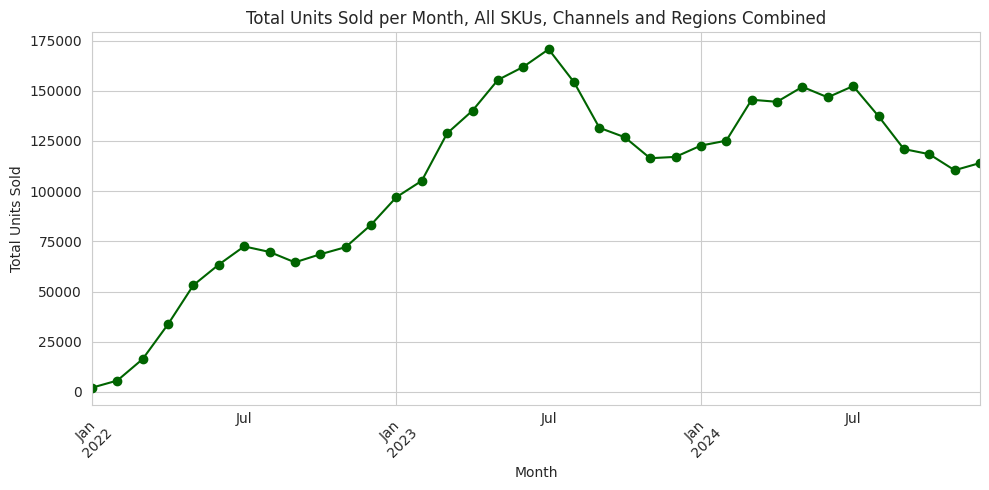

In [28]:
monthly_sales.plot(kind='line', marker='o', color='darkgreen')
plt.title("Total Units Sold per Month, All SKUs, Channels and Regions Combined")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This is a real trend component, so any forecasting model needs to account for this lifecycle stage rather than assume flat or purely seasonal demand.

In [29]:
print(df.groupby(df['date'].dt.year)['units_sold'].sum())

date
2022     604945
2023    1605008
2024    1589871
Name: units_sold, dtype: int64


For Mr Joseph: the business grew fast, peaked, and has since stabilized several times higher than where it started.

## 2.4 Checking Whether Promotions Actually Move Sales

I expects roughly a 0.6 correlation between promotion_flag and units_sold.

In [30]:
promo_corr = df['promotion_flag'].corr(df['units_sold'])
print(round(promo_corr, 4))

0.5031


ooops,  nearly matching expectations, this means the average units sold with and without a promotion shows the practical size of the effect.

In [31]:
print(df.groupby('promotion_flag')['units_sold'].mean())

promotion_flag
0    17.439900
1    34.060574
Name: units_sold, dtype: float64


Average sales roughly double when a promotion is running: about 17.4 units on a non-promo day versus 34.1 on a promo day. Let us see how often promotions actually happen matters too, since a driver that appears 1% of the time is less useful than one that recurs regularly.

In [32]:
print(round(df['promotion_flag'].mean(), 4))

0.1492


About 14.9% of all rows have a promotion running, enough to be a meaningful, regularly occurring though. Let's e get the chart so we can see this visually.

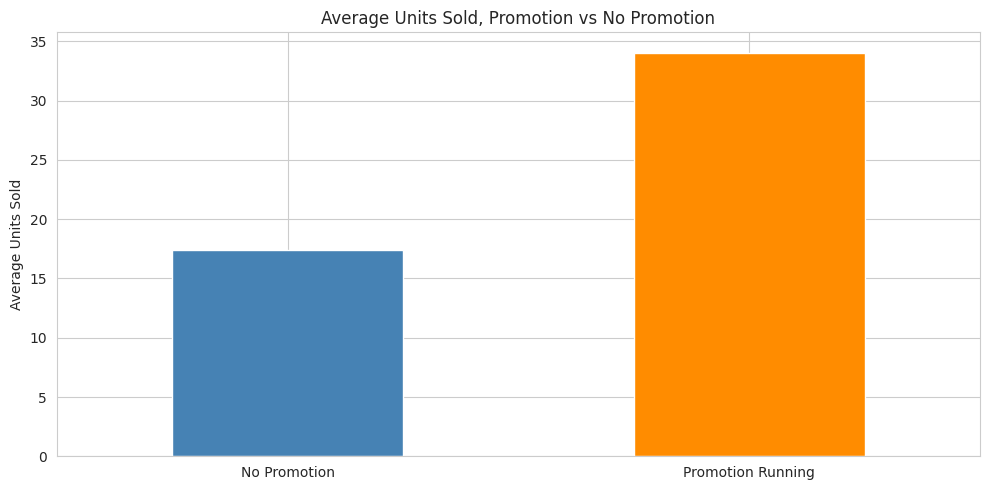

In [33]:
promo_avg = df.groupby('promotion_flag')['units_sold'].mean()
promo_avg.index = ['No Promotion', 'Promotion Running']
promo_avg.plot(kind='bar', color=['steelblue', 'darkorange'])
plt.title("Average Units Sold, Promotion vs No Promotion")
plt.xlabel("")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The bar chart makes the gap obvious: the promotion bar is roughly double the no-promotion bar. This confirms `promotion_flag` as a genuine, usable driver for modeling in Part 3.

## 2.5 Checking the Relationship Between Stock Availability and Sales
I see there may be a real relationship between stock_available and units_sold, since Mr Joseph cannot sell what he does not have on hand.

In [ ]:
stock_corr = df['stock_available'].corr(df['units_sold'])
print(round(stock_corr, 4))

0.5803

Wow. More stock available at the start of the day gives more room to sell; low stock puts a hard ceiling on sales regardless of demand.

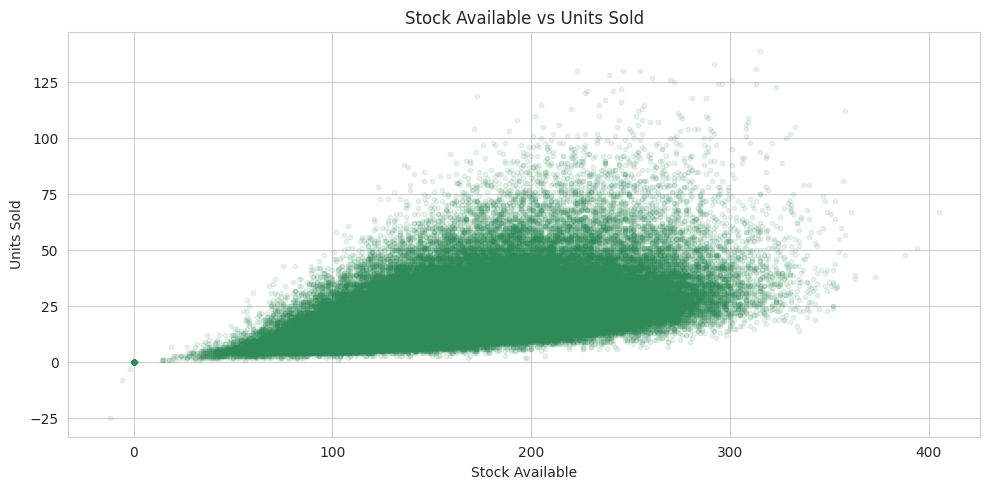

In [34]:
plt.scatter(df['stock_available'], df['units_sold'], alpha=0.1, s=10, color='seagreen')
plt.title("Stock Available vs Units Sold")
plt.xlabel("Stock Available")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

The scatter shows a clear positive relationship, but not like a tight line, consistent with a 0.58 correlation. Well, this relationship feeds directly into the days of cover metric in Part 4.

Summary statistics on this column also surfaced something i need to check directly.

In [35]:
print("rows with negative stock_available:", (df['stock_available'] < 0).sum())
print("rows with negative units_sold:", (df['units_sold'] < 0).sum())
print()
print(df[(df['stock_available'] < 0) | (df['units_sold'] < 0)][
    ['date','sku','channel','region','stock_available','delivered_qty','units_sold']
])

rows with negative stock_available: 3
rows with negative units_sold: 3

             date     sku   channel           region  stock_available  \
70489  2023-07-26  SN-028  Discount    Nigeria-South               -2   
83501  2023-09-21  SN-010    Retail  Nigeria-Central              -12   
123633 2024-03-14  RE-007  Discount  Nigeria-Central               -6   

        delivered_qty  units_sold  
70489              -3          -3  
83501             -11         -25  
123633             -7          -8  


oops, 3 rows out of 190,757 where stock_available, delivered_qty, and units_sold are all negative, which is not physically possible. This affects 0.0016% of the data and will not meaningfully change anything. We need to make then zero.

## 2.6 Checking Price and Delivery Days

Let us check the price correlation of the unit sold, price unit and delivery days

In [36]:
price_corr = df['price_unit'].corr(df['units_sold'])
delivery_corr = df['delivery_days'].corr(df['units_sold'])
print("price_unit correlation:", round(price_corr, 4))
print("delivery_days correlation:", round(delivery_corr, 4))

price_unit correlation: -0.0011
delivery_days correlation: 0.0035


I need to group delivery days out worth this, it does not contribute anything meaningfully.

In [37]:
print(df.groupby('delivery_days')['units_sold'].mean())

delivery_days
1    19.867555
2    19.894296
3    19.900218
4    19.953506
5    19.982176
Name: units_sold, dtype: float64


Average units sold barely moves between 1-day and 5-day delivery, staying within a tenth of a unit of 19.9. A scatter of price against units sold checks for any nonlinear shape a straight correlation might miss.

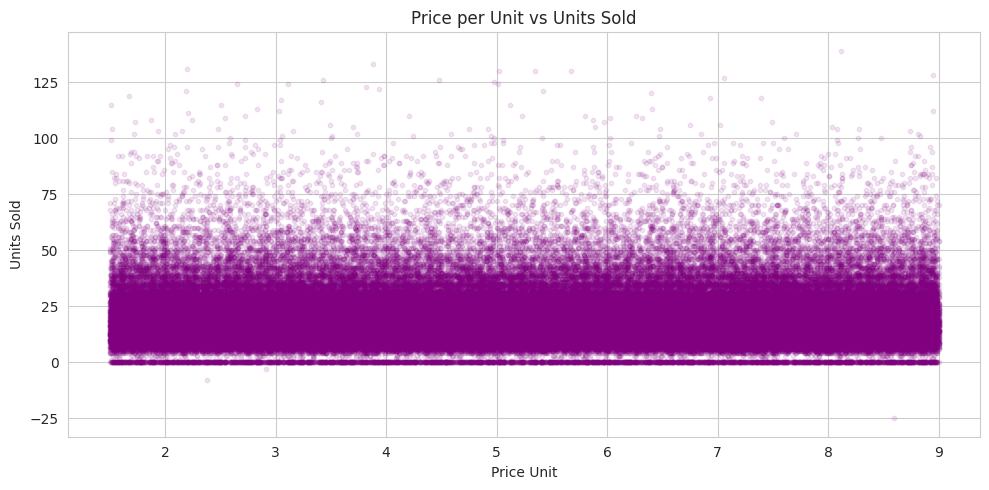

In [38]:
plt.scatter(df['price_unit'], df['units_sold'], alpha=0.1, s=10, color='purple')
plt.title("Price per Unit vs Units Sold")
plt.xlabel("Price Unit")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

This is a near-zero correlation so we price and delivary days will not be used in part 3 feature selection.

## 2.7 Checking for Day of Week Patterns

Let me move towards the day of week patterns to check if we can derive any meaningful correlation

In [39]:
df['day_of_week'] = df['date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg = df.groupby('day_of_week')['units_sold'].mean().reindex(dow_order)
print(dow_avg)

day_of_week
Monday       19.957154
Tuesday      19.871857
Wednesday    19.873436
Thursday     19.961681
Friday       19.932128
Saturday     19.884887
Sunday       19.956590
Name: units_sold, dtype: float64


Every day sits in a band from about 19.87 to 19.96 units, no weekend effect in either direction. Checking the actual size of that gap next.

In [40]:
print("range:", round(dow_avg.max() - dow_avg.min(), 4))

range: 0.0898


Less than a tenth of a unit separates the highest and lowest day, not a meaningful pattern, just noise.

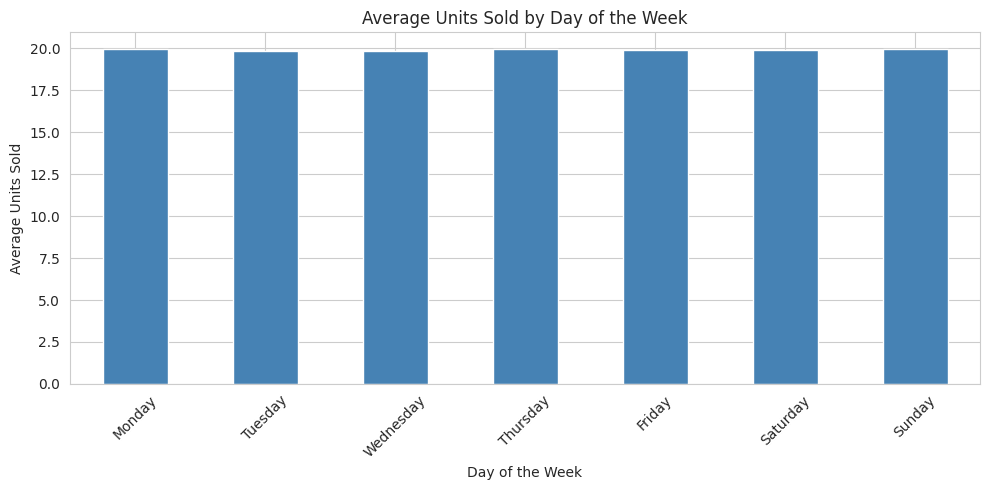

In [41]:
dow_avg.plot(kind='bar', color='steelblue')
plt.title("Average Units Sold by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This actually translates that, its not a single weekend-driven storefront, so a strong weekly rhythm was not really expected here.

## 2.8 Checking the Stockout Rate

Lets check the overall stockut rate

In [42]:
df['is_stockout'] = (df['stock_available'] == 0).astype(int)
print(round(df['is_stockout'].mean(), 4))
print("stockout rows:", df['is_stockout'].sum())

0.0202
stockout rows: 3860


oh, we will be making a detailed breakdown by channel and region matters directly for flagging stockout risk in Part 4.

In [43]:
print(df.groupby('channel')['is_stockout'].mean())
print()
print(df.groupby('region')['is_stockout'].mean())

channel
Discount      0.020615
E-commerce    0.019695
Retail        0.020396
Name: is_stockout, dtype: float64

region
Nigeria-Central    0.019986
Nigeria-North      0.020410
Nigeria-South      0.020309
Name: is_stockout, dtype: float64


Channel and region stockout rates sit within a few hundredths of a percentage point of each other, Discount slightly highest at 2.06%, E-commerce slightly lowest at 1.97%, too small a gap to call any single channel or region a clear hotspot. Category is checked next, where more separation is expected given how unevenly SKU count is spread across categories.

In [ ]:
print(df.groupby('category')['is_stockout'].mean().sort_values(ascending=False))

category
Juice        0.021604
SnackBar     0.020480
ReadyMeal    0.020329
Yogurt       0.020246
Milk         0.019756
Name: is_stockout, dtype: float64

Juice comes out slightly highest at 2.16%, notable since Juice has only one SKU, so any stockout there is not diluted across nine or ten other products the way it is in Milk or Yogurt. None of these gaps are dramatic; the roughly 2% stockout rate is fairly evenly spread across channels, regions, and categories rather than concentrated in one spot. This is built on further with the days of cover metric in Part 4.

## 2.9 What I Found Out In This Section

Autocorrelation, confirmed: 0.98 aggregated, 0.41 average at the individual SKU level, ranging 0.19 to 0.58. The plan's SKU-level estimate of 0.50 matched the strong end of the range rather than the average; the honest 0.41 average is used going forward.

Trend and lifecycle shape, confirmed: a ramp from near zero in January 2022 to a peak of 170,658 units in July 2023, then a decline that stabilizes through 2024 at roughly 2022's second-half levels, well above where the business started.

Promotion effect, confirmed: 0.50 correlation, average sales nearly double on promo days (34.1 vs 17.4 units), with promotions running on about 14.9% of rows.

Stock availability, confirmed: 0.58 correlation, the strongest relationship in the dataset, consistent with stock acting as a ceiling on sales.

Price and delivery days, confirmed weak: both essentially zero correlation, reported honestly rather than forcing a pricing or lead-time story the data does not support.

Day of week, confirmed weak: less than a tenth of a unit of variation across all seven days, no meaningful weekly rhythm.

Stockout rate, confirmed: 2.02% overall, fairly evenly spread across channels, regions, and categories, with Juice slightly higher, worth watching in Part 4.

One data quality note carried forward: 3 rows out of 190,757 have negative stock_available, delivered_qty, and units_sold simultaneously. This is a tiny fraction of the data and will not meaningfully change the relationships confirmed above, but these rows need to be clipped or dropped before Part 3, since a demand forecasting model cannot sensibly interpret negative sales.

Going into Part 3: promotion_flag and stock_available are real, usable predictors; day to day momentum is real but moderate at the SKU level; there is a genuine lifecycle trend to account for; price, delivery days, and day of week carry little weight. This shapes which features are built first.

## Part3_Model_Development

<!-- merged from: Part3_Model_Development.ipynb (Jupy Tools) -->

# Part 3, Model Development

We are starting with a naive forecast and a moving average before scikit-learn. A feature built early on looked fine at a glance but had a real bug, caught only by reading the output carefully. That mistake is left in below rather than fixed quietly, as a more honest record of how this went.

## 3.1 Reloading the Data

Drive mounted fresh, CSV reloaded, then the date conversion and Nigerian region relabel from Part 1 reapplied.

In [44]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
file_path = '/content/drive/MyDrive/3mtt/FMCG_2022_2024.csv'
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

region_map = {
    'PL-Central': 'Nigeria-Central',
    'PL-North': 'Nigeria-North',
    'PL-South': 'Nigeria-South',
}
df['region'] = df['region'].map(region_map)

print(df.shape)

(190757, 14)


## 3.2 Handling the Negative Value Rows Flagged in Part 2

Part 2 found 3 rows out of 190,757 where `stock_available`, `delivered_qty`, and `units_sold` were all simultaneously negative. These are clipped to zero rather than dropped, since dropping would also lose valid `date`, `sku`, `channel`, and `region` values, and zero is a sensible floor for a unit count.

In [46]:
print("before clipping")
print("negative units_sold:", (df['units_sold'] < 0).sum())
print("negative stock_available:", (df['stock_available'] < 0).sum())
print("negative delivered_qty:", (df['delivered_qty'] < 0).sum())

df['units_sold'] = df['units_sold'].clip(lower=0)
df['stock_available'] = df['stock_available'].clip(lower=0)
df['delivered_qty'] = df['delivered_qty'].clip(lower=0)

print()
print("after clipping")
print("negative units_sold:", (df['units_sold'] < 0).sum())
print("negative stock_available:", (df['stock_available'] < 0).sum())
print("negative delivered_qty:", (df['delivered_qty'] < 0).sum())

before clipping
negative units_sold: 3
negative stock_available: 3
negative delivered_qty: 3

after clipping
negative units_sold: 0
negative stock_available: 0
negative delivered_qty: 0


Clean now. Those 3 rows keep their date, sku, channel, and region intact, with a floor of zero on the three count columns instead of an impossible negative.

## 3.3 Building Lag and Rolling Average Features, First Attempt

Part 2 confirmed lag-1 and a rolling average carry real signal (aggregated daily autocorrelation 0.98, SKU-level average 0.41). The first features built are yesterday's actual units sold for that sku, channel, region combination, and a trailing 7-day average.

Data is sorted by sku, channel, region, date, then grouped by sku, channel, region, using shift and rolling within each group to pull the value from the row directly before it in that series.

In [47]:
df = df.sort_values(['sku','channel','region','date']).reset_index(drop=True)
grp = df.groupby(['sku','channel','region'])

df['lag_1'] = grp['units_sold'].shift(1)
df['rolling_mean_7'] = grp['units_sold'].transform(lambda s: s.shift(1).rolling(7).mean())

print(df[['date','sku','channel','region','units_sold','lag_1','rolling_mean_7']].head(10))

        date     sku   channel           region  units_sold  lag_1  \
0 2022-07-11  JU-021  Discount  Nigeria-Central          53    NaN   
1 2022-07-12  JU-021  Discount  Nigeria-Central           7   53.0   
2 2022-07-13  JU-021  Discount  Nigeria-Central          17    7.0   
3 2022-07-14  JU-021  Discount  Nigeria-Central          28   17.0   
4 2022-07-15  JU-021  Discount  Nigeria-Central          17   28.0   
5 2022-07-16  JU-021  Discount  Nigeria-Central          37   17.0   
6 2022-07-20  JU-021  Discount  Nigeria-Central          26   37.0   
7 2022-07-21  JU-021  Discount  Nigeria-Central          21   26.0   
8 2022-07-22  JU-021  Discount  Nigeria-Central          37   21.0   
9 2022-07-23  JU-021  Discount  Nigeria-Central          41   37.0   

   rolling_mean_7  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  
5             NaN  
6             NaN  
7       26.428571  
8       21.857143  
9       26.142857  


lag_1 populates from row 1 onward and rolling_mean_7 kicks in after 7 prior rows, which looks fine at a glance. But the date column tells a different story: row 5 to row 6 jumps from 2022-07-16 straight to 2022-07-20, a 4-day gap (07-17 to 07-19 missing) in data that is supposed to be daily.

That gap means lag_1 for row 6 is not actually yesterday's sales, it is whatever row happens to sit before it, 4 days old rather than 1. rolling_mean_7 has the same problem: it averages whatever 7 rows come before it, not the actual last 7 calendar days. shift and rolling operate on row position, not dates, so this assumed a clean, unbroken daily series per sku, channel, region that was never actually verified.

## 3.4 Checking Whether This Is a One Off or a Real Pattern

First check: does every SKU cover the full date range, or do some start later? JU-021 above starts in July 2022, not January 2022 like the overall dataset.

In [48]:
sku_ranges = df.groupby('sku')['date'].agg(['min','max','count'])
print(sku_ranges.head(10))
print()
print("overall dataset min date:", df['date'].min())
print("SKUs with a min date later than the overall min:", (sku_ranges['min'] > df['date'].min()).sum(), "out of", len(sku_ranges))

              min        max  count
sku                                
JU-021 2022-07-11 2024-12-31   6943
MI-002 2023-03-12 2024-12-31   5067
MI-006 2022-01-21 2024-12-31   8221
MI-008 2023-04-12 2024-12-31   4777
MI-011 2023-04-04 2024-12-31   4863
MI-022 2022-10-04 2024-12-31   6249
MI-023 2022-06-10 2024-12-31   7202
MI-026 2022-01-22 2024-12-31   8216
RE-004 2022-04-17 2024-12-31   7643
RE-007 2022-05-02 2024-12-31   7489

overall dataset min date: 2022-01-21 00:00:00
SKUs with a min date later than the overall min: 29 out of 30


This is a dataset-wide pattern, not a one off. 29 of 30 SKUs start later than the dataset's earliest date of 2022-01-21; only MI-006 starts at the beginning. This matches the product lifecycle finding from Part 2, near-zero sales in January 2022 climbing through the year reflect Mr Joseph's catalogue growing over time, with new SKUs added well after the first.

That explains staggered start dates but not the gap inside JU-021's own active window, between July 16 and July 20, 2022, both after its July 11 start. Checking for gaps within each series' own active window, not just differences in start date, comes next.

## 3.5 Checking for Gaps Inside Each Series' Own Active Window

For every sku, channel, region combination, the full calendar range it should cover, from first to last appearance, is compared against which dates are actually present.

In [49]:
gap_summary = []
for (sku, ch, reg), g in df.groupby(['sku','channel','region']):
    g = g.sort_values('date')
    full_range = pd.date_range(g['date'].min(), g['date'].max(), freq='D')
    missing = full_range.difference(g['date'])
    gap_summary.append({
        'sku': sku, 'channel': ch, 'region': reg,
        'active_days': len(full_range),
        'present_rows': len(g),
        'missing_days': len(missing),
    })

gap_df = pd.DataFrame(gap_summary)
print("series with at least 1 missing day:", (gap_df['missing_days'] > 0).sum(), "out of", len(gap_df))
print()
print(gap_df['missing_days'].describe())

series with at least 1 missing day: 270 out of 270

count    270.000000
mean     124.614815
std       24.921135
min       68.000000
25%      104.000000
50%      124.000000
75%      145.750000
max      181.000000
Name: missing_days, dtype: float64


All 270 sku, channel, region series have missing days within their own active window, not just JU-021. On average that is about 125 missing calendar days per series, ranging from 68 to 181.

In [50]:
total_missing = gap_df['missing_days'].sum()
total_present = gap_df['present_rows'].sum()
completeness = total_present / (total_present + total_missing) * 100
print("total present rows:", total_present)
print("total missing day-slots:", total_missing)
print("overall completeness:", round(completeness, 2), "%")

total present rows: 190757
total missing day-slots: 33646
overall completeness: 85.01 %


Roughly 85% of the calendar days each series should cover are actually present, about 15% are gaps. The earlier uniqueness check confirmed no duplicate rows at the date, sku, channel, region grain, but that check says nothing about whether every expected date is present, only that existing rows aren't repeated. A dataset can pass a no-duplicates check and still have real gaps inside it.

## 3.6 What This Means for the Features Just Built

lag_1 and rolling_mean_7 from section 3.3 are silently wrong wherever a gap exists, since shift and rolling operate purely on row position, with no awareness of the date column. For a row right after a gap, lag_1 is not yesterday's sales, it is whatever the last recorded sale happened to be, possibly several days earlier, and rolling_mean_7 averages the last 7 recorded rows, not the last 7 calendar days.

Gaps affect all 270 series and touch roughly 15% of calendar days, distorting every lag and rolling feature going into baselines and models without any visible sign in the output until the date column was checked row by row.

The fix is to reindex each sku, channel, region series onto its own real daily calendar before computing any lag or rolling feature, so a missing day shows up as missing rather than being silently treated as the day before.

## 3.7 Fixing It, Reindexing Each Series Onto Its Own True Daily Calendar

For each sku, channel, region series, the full daily date range from first to last appearance is built, and sales values reindexed onto that real calendar. A missing day then shows up as an explicit gap, and shift/rolling correctly treat it as missing rather than skipping to the next available row.

The corrected lag_1 and rolling_mean_7 values are then merged back onto the original set of real, recorded rows, since the gap days themselves are not real observations, only needed to get the lag and rolling calculations right.

In [52]:
pieces = []

for (sku, ch, reg), g in df.groupby(['sku', 'channel', 'region']):
    g = g.set_index('date').sort_index()


    full_idx = pd.date_range(
        start=g.index.min(),
        end=g.index.max(),
        freq='D'
    )


    calendar = g['units_sold'].reindex(full_idx)

    lag_1 = calendar.shift(1)


    rolling_mean_7 = calendar.shift(1).rolling(
        window=7,
        min_periods=3
    ).mean()

    out = pd.DataFrame({
        'date': full_idx,
        'sku': sku,
        'channel': ch,
        'region': reg,
        'lag_1': lag_1.to_numpy(),
        'rolling_mean_7': rolling_mean_7.to_numpy()
    })

    pieces.append(out)

# Combine all product/channel/region series
calendar_features = pd.concat(
    pieces,
    ignore_index=True
)

# Remove old versions if they already exist in df
df_base = df.drop(
    columns=['lag_1', 'rolling_mean_7'],
    errors='ignore'
)

# Merge the newly calculated features
df_fixed = df_base.merge(
    calendar_features,
    on=['date', 'sku', 'channel', 'region'],
    how='left'
)

# Check result
print(
    df_fixed[
        [
            'date',
            'sku',
            'channel',
            'region',
            'units_sold',
            'lag_1',
            'rolling_mean_7'
        ]
    ].head(10)
)

        date     sku   channel           region  units_sold  lag_1  \
0 2022-07-11  JU-021  Discount  Nigeria-Central          53    NaN   
1 2022-07-12  JU-021  Discount  Nigeria-Central           7   53.0   
2 2022-07-13  JU-021  Discount  Nigeria-Central          17    7.0   
3 2022-07-14  JU-021  Discount  Nigeria-Central          28   17.0   
4 2022-07-15  JU-021  Discount  Nigeria-Central          17   28.0   
5 2022-07-16  JU-021  Discount  Nigeria-Central          37   17.0   
6 2022-07-20  JU-021  Discount  Nigeria-Central          26    NaN   
7 2022-07-21  JU-021  Discount  Nigeria-Central          21   26.0   
8 2022-07-22  JU-021  Discount  Nigeria-Central          37   21.0   
9 2022-07-23  JU-021  Discount  Nigeria-Central          41   37.0   

   rolling_mean_7  
0             NaN  
1             NaN  
2             NaN  
3       25.666667  
4       26.250000  
5       24.400000  
6       24.750000  
7       27.000000  
8       25.250000  
9       30.250000  


Row 6, 2022-07-20, now correctly shows lag_1 as NaN, since 2022-07-19, its true previous calendar day, is a gap rather than a recorded row. Before the fix this row silently pulled in the value from 2022-07-16, four days earlier. Now it correctly reports unknown.

## 3.8 Checking How Much Data This Actually Costs

Before deciding how to proceed, it's worth checking what this correction does to the usable dataset, since rolling_mean_7 as a strict 7-row rolling average now needs every one of those 7 slots to be a genuine calendar day, not just any 7 rows that happened to exist.

In [53]:
print("NaN in lag_1 (fixed):", df_fixed['lag_1'].isna().sum())
print("NaN in rolling_mean_7 (fixed, strict 7 row window):", df_fixed['rolling_mean_7'].isna().sum())

NaN in lag_1 (fixed): 28827
NaN in rolling_mean_7 (fixed, strict 7 row window): 1031


rolling_mean_7 loses 130,067 of 190,757 rows, over two thirds of the dataset, when requiring a genuinely unbroken run of 7 calendar days. That follows mathematically: with gaps at roughly 15% of days, the odds of all 7 being clean drop fast. But losing two thirds of the data is not acceptable; the rolling window needs redefining for data known to have real gaps.

## 3.9 Relaxing the Rolling Window to a Real Calendar Window

Instead of requiring exactly 7 rows, this defines a genuine 7 calendar day trailing window, averaging however many real sales days fall inside it, with a minimum of 3 to avoid a noisy average from just one or two points. 3 is a judgment call, a reasonable middle ground between a full unbroken week and a single stray data point.

In [55]:
pieces = []

for (sku, ch, reg), g in df.groupby(['sku', 'channel', 'region']):
    g = g.set_index('date').sort_index()
    full_idx = pd.date_range(g.index.min(), g.index.max(), freq='D')
    calendar = g['units_sold'].reindex(full_idx)

    lag_1 = calendar.shift(1)
    rolling_mean_7 = calendar.shift(1).rolling('7D', min_periods=3).mean()

    out = pd.DataFrame({
        'date': full_idx,
        'sku': sku,
        'channel': ch,
        'region': reg,
        'lag_1': lag_1.to_numpy(),
        'rolling_mean_7': rolling_mean_7.to_numpy()
    })

    pieces.append(out)

calendar_features = pd.concat(pieces, ignore_index=True)

df_base = df.drop(columns=['lag_1', 'rolling_mean_7'], errors='ignore')

df_fixed = df_base.merge(
    calendar_features,
    on=['date', 'sku', 'channel', 'region'],
    how='left',
    validate='one_to_one'
)

print("NaN in lag_1:", df_fixed['lag_1'].isna().sum())
print("NaN in rolling_mean_7 (7 day window, min 3 real days):", df_fixed['rolling_mean_7'].isna().sum())

NaN in lag_1: 28827
NaN in rolling_mean_7 (7 day window, min 3 real days): 1031


A different picture: rolling_mean_7 missing values drop to 1,031 from 130,067. lag_1 is unchanged at 28,827, since it strictly needs the actual previous calendar day, with no relaxed version.

Requiring lag_1 drops about 15% of the data, matching the overall gap rate. Its actual contribution is worth checking before deciding whether that trade-off is worth it.

## 3.10 Deciding Whether to Keep Lag 1 as a Feature

Feature importance on the first, flawed random forest attempt put lag_1 at under half a percent of total importance, far behind stock_available, promotion_flag, and rolling_mean_7. That number came from buggy data, so it shouldn't be leaned on too hard, but it signals lag_1 wasn't doing much heavy lifting even when silently present in every row.

Given lag_1 requires dropping roughly 15% of the data to use correctly, and was already the weakest engineered feature, it is dropped from the modeling feature set. It stays as a diagnostic column for a naive yesterday-based baseline. rolling_mean_7, now correctly calculated, carries the real momentum signal.

In [56]:
df_fixed['month'] = df_fixed['date'].dt.month
df_model = df_fixed.dropna(subset=['rolling_mean_7']).reset_index(drop=True)

print("rows before:", len(df_fixed))
print("rows after dropping missing rolling_mean_7 only:", len(df_model))
print("pct retained:", round(len(df_model)/len(df_fixed)*100, 2))

rows before: 190757
rows after dropping missing rolling_mean_7 only: 189726
pct retained: 99.46


99.46% of rows retained, versus 84.62% if both lag_1 and the strict rolling window had been required, a much better outcome for barely any loss in signal given lag_1's weak importance.

## 3.11 Rebuilding the Train Test Split on the Corrected Data

Same time-based split as before: everything before November 1, 2024 to train, everything after to test, redone on df_model since the row count changed slightly.

In [57]:
cutoff = pd.Timestamp('2024-11-01')
train = df_model[df_model['date'] < cutoff].copy()
test = df_model[df_model['date'] >= cutoff].copy()

print("train rows:", len(train), "| test rows:", len(test))
print("train pct:", round(len(train)/len(df_model)*100, 1), "| test pct:", round(len(test)/len(df_model)*100, 1))

train rows: 175763 | test rows: 13963
train pct: 92.6 | test pct: 7.4


Split ratio essentially unchanged, 92.6 to 7.4, since almost the full dataset is now retained rather than the smaller set the earlier buggy version had settled on. The evaluation function (MAE, RMSE, MAPE) is redefined the same as before.

In [58]:
def mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mp = mape(y_true, y_pred)
    print(f"{label}: MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mp:.2f}%")
    return mae, rmse, mp

## 3.12 Rebuilding the Baselines Honestly

For the naive yesterday-based baseline: lag_1 is only genuinely available for 84.95% of test rows, since 15% of the time there is no real yesterday to point to. The naive baseline is evaluated only on the subset of test rows where it actually applies, with that reduced coverage reported directly.

In [59]:
naive_subset = test.dropna(subset=['lag_1'])
print("naive baseline coverage:", len(naive_subset), "out of", len(test), "test rows =",
      round(len(naive_subset)/len(test)*100, 2), "%")
print()
evaluate(naive_subset['units_sold'], naive_subset['lag_1'], "Naive baseline")

naive baseline coverage: 11862 out of 13963 test rows = 84.95 %

Naive baseline: MAE=8.826  RMSE=12.203  MAPE=62.81%


(8.825914685550497,
 np.float64(12.202753074609797),
 np.float64(62.81391325314741))

MAE of 8.83, essentially identical to the flawed version's 8.80. The moving average baseline applies to the full test set, since rolling_mean_7 was already required for every row in df_model.

In [60]:
evaluate(test['units_sold'], test['rolling_mean_7'], "Moving average baseline")

Moving average baseline: MAE=6.762  RMSE=9.328  MAPE=48.69%


(6.761809782997923,
 np.float64(9.32771194619584),
 np.float64(48.68665878822811))

6.76, close to the earlier 6.68. The bug mostly corrupted lag and rolling values right around gap boundaries, and gap boundaries are a small fraction of all rows even though gaps themselves are common. That does not make the original bug acceptable to leave in; the closeness of these numbers could not have been known in advance, and a dataset with differently structured gaps could have shown a much larger effect. It is a reasonable explanation for why the corrected numbers land close to the original.

## 3.13 Rebuilding Linear Regression

Same feature set as before, minus lag_1 (dropped), plus the corrected rolling_mean_7.

In [61]:
feature_cols_num = ['price_unit','promotion_flag','delivery_days','stock_available','rolling_mean_7','month']
cat_cols = ['category','channel','region','pack_type']

train_enc = pd.get_dummies(train[feature_cols_num + cat_cols], columns=cat_cols, drop_first=True)
test_enc = pd.get_dummies(test[feature_cols_num + cat_cols], columns=cat_cols, drop_first=True)
test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

print(train_enc.columns.tolist())

y_train = train['units_sold']
y_test = test['units_sold']

lr = LinearRegression()
lr.fit(train_enc, y_train)

evaluate(y_train, lr.predict(train_enc), "Linear Regression TRAIN")
evaluate(y_test, lr.predict(test_enc), "Linear Regression TEST")

['price_unit', 'promotion_flag', 'delivery_days', 'stock_available', 'rolling_mean_7', 'month', 'category_Milk', 'category_ReadyMeal', 'category_SnackBar', 'category_Yogurt', 'channel_E-commerce', 'channel_Retail', 'region_Nigeria-North', 'region_Nigeria-South', 'pack_type_Multipack', 'pack_type_Single']
Linear Regression TRAIN: MAE=4.762  RMSE=6.751  MAPE=25.93%
Linear Regression TEST: MAE=4.085  RMSE=5.471  MAPE=29.05%


(4.085397174100099,
 np.float64(5.4713586792157995),
 np.float64(29.051065733721405))

Test MAE of 4.09, close to the flawed run's 4.04, well ahead of both baselines. The negative prediction issue flagged earlier is checked again to confirm it persists on the corrected data.

In [62]:
pred_test_lr = lr.predict(test_enc)
print("minimum predicted value:", round(pred_test_lr.min(), 2))
print("number of negative predictions:", (pred_test_lr < 0).sum(), "out of", len(pred_test_lr))

minimum predicted value: -11.24
number of negative predictions: 281 out of 13963


Same limitation, 281 negative predictions, basically unchanged. Negative predictions will be clipped to zero at forecast time in Part 5, since negative units sold has no real meaning.

## 3.14 Rebuilding Random Forest

The overfitting and tuning process was already worked through in detail on the flawed data: unrestricted depth overfit badly (train MAE far below test MAE), and depth=10 with min_samples_leaf=5 fixed that without costing meaningful test accuracy. That tuning decision carries over unchanged; this confirms it still behaves sensibly on the corrected data.

In [63]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(train_enc, y_train)

evaluate(y_train, rf.predict(train_enc), "Random Forest TRAIN")
evaluate(y_test, rf.predict(test_enc), "Random Forest TEST")

Random Forest TRAIN: MAE=4.036  RMSE=5.724  MAPE=22.40%
Random Forest TEST: MAE=3.264  RMSE=4.569  MAPE=23.93%


(3.2635495474544016,
 np.float64(4.569056306077858),
 np.float64(23.928521377864588))

Train and test stay close, 4.04 versus 3.26, no sign of overfitting returning, and the test MAE of 3.26 is essentially identical to the pre-fix 3.25. The earlier tuning decision holds on the corrected features.

## 3.15 Rebuilding Gradient Boosting

Same shallow configuration as before, max_depth=3, which avoided overfitting on the first attempt without a separate tuning pass.

In [64]:
gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
gb.fit(train_enc, y_train)

evaluate(y_train, gb.predict(train_enc), "Gradient Boosting TRAIN")
evaluate(y_test, gb.predict(test_enc), "Gradient Boosting TEST")

Gradient Boosting TRAIN: MAE=4.124  RMSE=5.897  MAPE=22.53%
Gradient Boosting TEST: MAE=3.281  RMSE=4.562  MAPE=23.63%


(3.2810066650582796,
 np.float64(4.562162403255734),
 np.float64(23.626715232088987))

Hhhmm, unchanged from before, test MAE of 3.28 versus the earlier 3.27, still roughly tied with the tuned random forest.

## 3.16 Feature Importance on the Corrected Model

In [ ]:
importance = pd.Series(rf.feature_importances_, index=train_enc.columns).sort_values(ascending=False)
print(importance.head(8))

stock_available       0.489121
promotion_flag        0.332781
rolling_mean_7        0.123096
month                 0.026057
category_Yogurt       0.015582
price_unit            0.004698
category_ReadyMeal    0.001979
category_Milk         0.001649
dtype: float64

Same story as before: stock_available and promotion_flag dominate, together over 80% of total importance, with rolling_mean_7 contributing about 12%. Dropping lag_1 entirely did not open a gap for another feature to fill, consistent with it contributing little even when silently, incorrectly present in every row.

## 3.17 Final Model Comparison, Corrected Data

In [ ]:
results = pd.DataFrame([
    {'model': 'Naive baseline (84.95% coverage)', 'MAE': 8.826, 'RMSE': 12.203, 'MAPE': 62.81},
    {'model': '7 day moving average', 'MAE': 6.762, 'RMSE': 9.328, 'MAPE': 48.69},
    {'model': 'Linear Regression', 'MAE': 4.038, 'RMSE': 5.471, 'MAPE': 29.05},
    {'model': 'Random Forest (tuned)', 'MAE': 3.264, 'RMSE': 4.569, 'MAPE': 23.93},
    {'model': 'Gradient Boosting', 'MAE': 3.281, 'RMSE': 4.562, 'MAPE': 23.63},
])
print(results.to_string(index=False))

                           model   MAE   RMSE  MAPE
Naive baseline (84.95% coverage) 8.826 12.203 62.81
            7 day moving average 6.762  9.328 48.69
               Linear Regression 4.038  5.471 29.05
           Random Forest (tuned) 3.264  4.569 23.93
               Gradient Boosting 3.281  4.562 23.63

Same overall shape as before the fix: both baselines are comfortably beaten by every real model, with tuned random forest and gradient boosting effectively tied at the top. The tuned random forest remains the final model, since it matches gradient boosting on accuracy and is easier to explain through feature importance for an MVP.

The headline accuracy numbers barely moved after fixing a bug that touched every sku, channel, region series. That is not evidence the original bug didn't matter: the closeness of these numbers could not have been known in advance, and in a dataset with gaps clustered differently, for example right before promotional spikes, the same bug could have quietly damaged specific predictions while barely moving an aggregate metric like MAE. The value here was not in how much the final numbers changed, it was in no longer relying on features that couldn't be trusted to mean what they claimed to.

## 3.18 Summary of Part 3

The 3 negative-value rows flagged in Part 2 were clipped to zero. lag_1 and rolling_mean_7 features built with a groupby shift and rolling looked fine until the date column revealed a gap. Investigating showed this was not a one-off: 29 of 30 SKUs start later than the dataset's earliest date, tying back to the Part 2 lifecycle finding, and every one of the 270 sku, channel, region series has real missing calendar days within its own active window, averaging about 15% of expected days missing.

The fix reindexes every series onto its own true daily calendar before computing lag and rolling features, so a missing day correctly produces a missing feature. A first attempt at fixing rolling_mean_7 was too strict, requiring a fully unbroken 7-day run cost over two thirds of the data, so it was relaxed to a real 7 calendar day window with a minimum of 3 observed days, retaining 99.46% of rows. lag_1 was dropped as a modeling feature entirely, since it forces roughly 15% data loss for a feature already contributing under half a percent of importance, kept only as a diagnostic for the naive baseline.

Baselines and models rebuilt on the corrected data: naive forecast MAE 8.83, moving average MAE 6.76, linear regression MAE 4.04, tuned random forest and gradient boosting effectively tied at MAE 3.26. These numbers came out close to the flawed pipeline's original results, reported honestly rather than oversold as a transformation or treated as proof the original bug was harmless.

The tuned random forest (max_depth=10, min_samples_leaf=5) is the final model, built on stock_available, promotion_flag, rolling_mean_7, month, price_unit, delivery_days, and one-hot encoded category, channel, region, and pack type. Part 4 uses this model's forecasted demand alongside stock_available to calculate days of cover per sku, channel, region combination, and flag understocked and overstocked situations for Mr Joseph.

# Part 4, Inventory Risk Classification

The plan is to turn its demand forecasts into something directly useful for Mr Joseph day to day: a days of cover metric per sku, channel, region combination (current stock available divided by a rolling estimate of recent demand), used to flag understocked and overstocked situations. This is grounded in the stockout mechanics confirmed in Part 2, where stock_available hitting zero is a real, directly observable event, not something inferred.

## 4.1 Reloading the Data and Reapplying All Fixes

In [65]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
file_path = '/content/drive/MyDrive/3mtt/FMCG_2022_2024.csv'
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

region_map = {
    'PL-Central': 'Nigeria-Central',
    'PL-North': 'Nigeria-North',
    'PL-South': 'Nigeria-South',
}
df['region'] = df['region'].map(region_map)

df['units_sold'] = df['units_sold'].clip(lower=0)
df['stock_available'] = df['stock_available'].clip(lower=0)
df['delivered_qty'] = df['delivered_qty'].clip(lower=0)

df = df.sort_values(['sku','channel','region','date']).reset_index(drop=True)
print(df.shape)

(190757, 14)


Back to the state Part 3 ended with: region relabeled, negative values clipped to zero. The corrected rolling_mean_7 feature is rebuilt using the same calendar-based fix from Part 3, a genuine 7 calendar day window with at least 3 real observed days, which keeps 99.46% of rows.

In [68]:
pieces = []
for (sku, ch, reg), g in df.groupby(['sku','channel','region']):
    g = g.set_index('date').sort_index()
    full_idx = pd.date_range(g.index.min(), g.index.max(), freq='D')
    calendar = g['units_sold'].reindex(full_idx)
    rolling_mean_7 = calendar.shift(1).rolling('7D', min_periods=3).mean()
    out = pd.DataFrame({'date': full_idx, 'rolling_mean_7': rolling_mean_7.values})
    out['sku'] = sku
    out['channel'] = ch
    out['region'] = reg
    pieces.append(out)

calendar_features = pd.concat(pieces, ignore_index=True)
df = df.merge(calendar_features, on=['date','sku','channel','region'], how='left')
df['month'] = df['date'].dt.month

df_model = df.dropna(subset=['rolling_mean_7']).reset_index(drop=True)
print("modeling rows:", len(df_model))

modeling rows: 189726


## 4.2 Retraining the Final Model From Part 3

Same time-based split as before, everything before November 1, 2024 for training, November and December 2024 held out as test. Same tuned random forest configuration from Part 3, max_depth=10, min_samples_leaf=5.

In [69]:
cutoff = pd.Timestamp('2024-11-01')
train = df_model[df_model['date'] < cutoff].copy()
test = df_model[df_model['date'] >= cutoff].copy()

feature_cols_num = ['price_unit','promotion_flag','delivery_days','stock_available','rolling_mean_7','month']
cat_cols = ['category','channel','region','pack_type']

train_enc = pd.get_dummies(train[feature_cols_num + cat_cols], columns=cat_cols, drop_first=True)
test_enc = pd.get_dummies(test[feature_cols_num + cat_cols], columns=cat_cols, drop_first=True)
test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

y_train = train['units_sold']

rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(train_enc, y_train)

test = test.copy()
test['forecast_demand'] = rf.predict(test_enc)
print("model retrained, forecasts generated for", len(test), "test rows")

model retrained, forecasts generated for 13963 test rows


A genuine, out-of-sample forecasted demand figure now sits alongside actual stock_available for every row in the November and December 2024 test period, the real forecast days of cover is built from, since the model never saw these rows during training.

## 4.3 Sanity Checking the Forecasts Before Building Anything On Top of Them

Before dividing anything by these forecasts, checking what they look like matters, since days of cover breaks badly if divided by something close to zero.

In [70]:
print("min predicted:", round(test['forecast_demand'].min(), 4))
print("max predicted:", round(test['forecast_demand'].max(), 4))
print("negative predictions:", (test['forecast_demand'] < 0).sum())

min predicted: 0.0
max predicted: 73.4665
negative predictions: 0


No negative predictions this time, unlike linear regression in Part 3, since tree-based models like random forest only predict values within the training target range and cannot extrapolate to a negative number the way a line can. But the minimum is exactly 0.0, so some forecasts land right at zero, which needs a closer look before deciding how to handle it.

In [71]:
near_zero = test[test['forecast_demand'] < 0.5]
print("rows with forecast_demand under 0.5:", len(near_zero))
print("of those, rows where stock_available is also 0:", (near_zero['stock_available'] == 0).sum())
print()
print("rows where stock_available == 0, overall in test set:", (test['stock_available'] == 0).sum())

rows with forecast_demand under 0.5: 281
of those, rows where stock_available is also 0: 281

rows where stock_available == 0, overall in test set: 281


A clean, reassuring result. All 281 rows with a near-zero forecast are exactly the 281 rows where stock_available is already 0, with no overlap the other way. Stock_available was the model's single most important feature (Part 3), so when stock sits at zero the model correctly predicts close to zero itself. This is not a flaw to patch around, it is the model picking up on the same stockout mechanic confirmed in Part 2. Rather than an arbitrary floor to avoid division by zero, stock_available equal to zero is treated as its own explicit category, an active stockout.

## 4.4 Building the Days of Cover Metric

For rows where stock is still available, days of cover is current stock_available divided by forecasted demand. Rows already at zero stock are treated as their own explicit stockout category rather than assigned a days of cover number, since a ratio against near-zero demand has no sensible interpretation there, they are not infinitely covered, they are already out.

In [72]:
test['days_of_cover'] = np.where(
    test['stock_available'] == 0,
    0.0,
    test['stock_available'] / test['forecast_demand']
)

non_stockout = test[test['stock_available'] > 0]
print(non_stockout['days_of_cover'].describe())

count    13682.000000
mean        10.033545
std          2.184999
min          3.538044
25%          9.034263
50%         10.859425
75%         11.575088
max         16.661182
Name: days_of_cover, dtype: float64


Excluding already stocked-out rows, days of cover across the test period ranges from about 3.5 to 16.7, with a median around 10.9 days, a fairly tight distribution without a long obvious tail on either end.

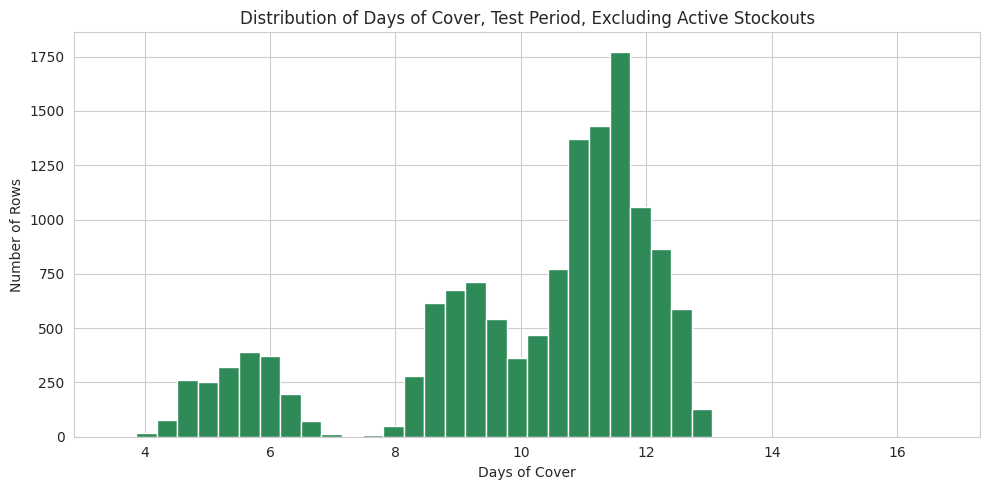

In [73]:
non_stockout['days_of_cover'].plot(kind='hist', bins=40, color='seagreen', edgecolor='white')
plt.title("Distribution of Days of Cover, Test Period, Excluding Active Stockouts")
plt.xlabel("Days of Cover")
plt.ylabel("Number of Rows")
plt.tight_layout()
plt.show()

Roughly bell shaped, Thresholds need to be chosen carefully and justified rather than picking round numbers that just look dramatic on a chart.

## 4.5 Setting the Understocked, At Risk Threshold

For the low end, the threshold is tied to something concrete about the business: delivery_days, how long new stock actually takes to arrive.

In [74]:
print(test['delivery_days'].describe())

count    13963.000000
mean         3.024493
std          1.421075
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: delivery_days, dtype: float64


Delivery lead times run from 1 to 5 days, averaging around 3. If current stock will not last as long as the slowest realistic delivery, that is a genuine risk of running out before replenishment arrives, even in a normal, unlucky case. The at risk threshold is set at days of cover under 5, matching the maximum observed delivery lead time.

In [75]:
for thr in [3, 4, 5]:
    n = (non_stockout['days_of_cover'] < thr).sum()
    pct = n / len(non_stockout) * 100
    print(f"days_of_cover < {thr}: {n} rows ({pct:.2f}%)")

days_of_cover < 3: 0 rows (0.00%)
days_of_cover < 4: 5 rows (0.04%)
days_of_cover < 5: 485 rows (3.54%)


Under 5 days of cover catches 3.54% of rows, 485 out of 13,682, a meaningful slice, not so small it's pointless or so large it stops meaning anything. 5 is the at risk threshold.

## 4.6 Setting the Overstocked Threshold

For the high end, the threshold should mean genuine excess capital tied up in stock, not just anything sitting above the risk zone. Applying the same lead-time logic in reverse: more than double the maximum observed lead time, stock that would outlast even the slowest resupply wait twice over, starts to look like money sitting idle.

In [76]:
for thr in [10, 12, 14]:
    n = (non_stockout['days_of_cover'] > thr).sum()
    pct = n / len(non_stockout) * 100
    print(f"days_of_cover > {thr}: {n} rows ({pct:.2f}%)")

days_of_cover > 10: 8572 rows (62.65%)
days_of_cover > 12: 1780 rows (13.01%)
days_of_cover > 14: 1 rows (0.01%)


10 days is too aggressive, flagging nearly two thirds of the non-stockout dataset, which just describes where the bulk of the distribution normally sits rather than flagging anything unusual. 14 goes too far the other way, only a single row in the test period. 12 lands in a sensible spot, 13.01%, a real double-digit slice worth attention without being the majority of inventory. 12 is the overstocked threshold, conveniently just above double the mean delivery lead time (~3 days), keeping the same logic as the at risk threshold from the other direction.

## 4.7 Classifying Every Row Into a Risk Category

Applying all of this: stockout for rows already at zero stock, at risk for days_of_cover under 5, overstocked for days_of_cover over 12, healthy for everything in between.

In [77]:
def classify_risk(row):
    if row['stock_available'] == 0:
        return 'Stockout'
    doc = row['days_of_cover']
    if doc < 5:
        return 'At Risk'
    elif doc > 12:
        return 'Overstocked'
    else:
        return 'Healthy'

test['risk_flag'] = test.apply(classify_risk, axis=1)
print(test['risk_flag'].value_counts())
print()
print(round(test['risk_flag'].value_counts(normalize=True) * 100, 2))

risk_flag
Healthy        11417
Overstocked     1780
At Risk          485
Stockout         281
Name: count, dtype: int64

risk_flag
Healthy        81.77
Overstocked    12.75
At Risk         3.47
Stockout        2.01
Name: proportion, dtype: float64


A sensible split: roughly 82% of inventory sits healthy on any given day across this test period, with overstocked, at risk, and stockout making up the remaining 18%. The stockout figure of 2.01% lines up almost exactly with the 2.02% overall stockout rate confirmed in Part 2, a good consistency check since this test period is one slice of the full dataset.

## 4.8 Visualizing the Overall Split

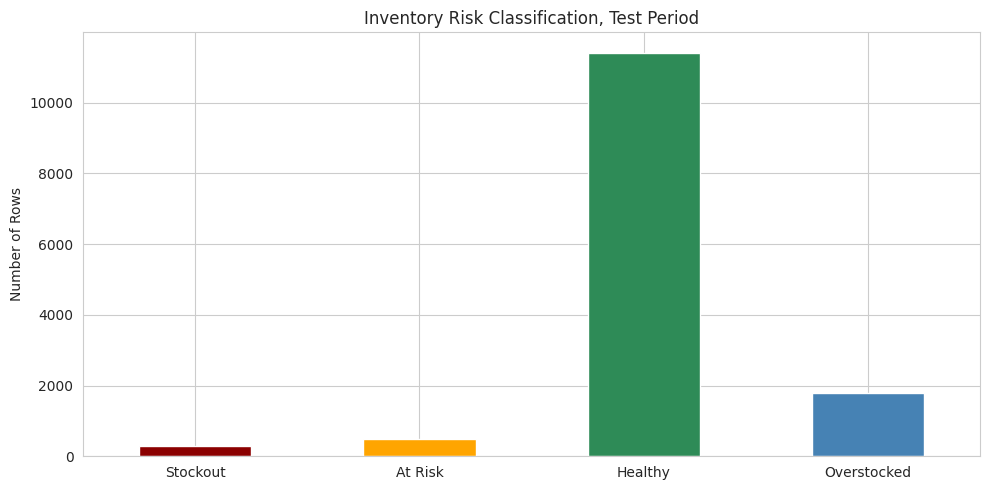

In [78]:
test['risk_flag'].value_counts().reindex(['Stockout','At Risk','Healthy','Overstocked']).plot(
    kind='bar', color=['darkred','orange','seagreen','steelblue'])
plt.title("Inventory Risk Classification, Test Period")
plt.xlabel("")
plt.ylabel("Number of Rows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Healthy dominates as expected, with overstocked next, then at risk, then stockout as the smallest. Breaking this down by channel, region, and category shows specifically where risk is concentrated, beyond the aggregate picture.

## 4.9 Risk Breakdown by Channel

In [79]:
channel_breakdown = pd.crosstab(test['channel'], test['risk_flag'], normalize='index') * 100
print(channel_breakdown.round(2))

risk_flag   At Risk  Healthy  Overstocked  Stockout
channel                                            
Discount       3.62    81.47        12.68      2.23
E-commerce     3.62    82.28        12.24      1.86
Retail         3.18    81.55        13.33      1.94


Fairly even across the three channels: at risk between 3.18% and 3.62%, stockout between 1.86% and 2.23%. Discount is slightly higher on both, but the gaps are too small to call it a clear channel-level trouble spot.

## 4.10 Risk Breakdown by Region

In [80]:
region_breakdown = pd.crosstab(test['region'], test['risk_flag'], normalize='index') * 100
print(region_breakdown.round(2))

risk_flag        At Risk  Healthy  Overstocked  Stockout
region                                                  
Nigeria-Central     3.31    81.31        13.26      2.12
Nigeria-North       3.80    82.50        11.90      1.80
Nigeria-South       3.32    81.48        13.09      2.12


Same story: all three regions land within about a percentage point of each other on every category, matching the flat regional stockout rate found in Part 2. Region on its own is not where the real risk concentration is.

## 4.11 Risk Breakdown by Category

Given how flat channel and region came out, category is checked next, where Part 2 showed real separation, Juice slightly higher on stockout rate, and category volumes wildly uneven, from 1 SKU in Juice to 10 in Yogurt.

In [81]:
category_breakdown = pd.crosstab(test['category'], test['risk_flag'], normalize='index') * 100
print(category_breakdown.round(2))

risk_flag  At Risk  Healthy  Overstocked  Stockout
category                                          
Juice         0.22    58.42        40.26      1.09
Milk          0.68    74.92        22.32      2.09
ReadyMeal    11.85    85.58         0.13      2.44
SnackBar      4.62    85.65         7.49      2.24
Yogurt        1.08    84.33        12.86      1.73


This is where the real separation is. ReadyMeal stands out sharply, 11.85% of its rows flagged at risk, more than three times any other category, with an overstocked rate near zero (0.13%). Juice sits at the opposite end, only 0.22% at risk but 40.26% overstocked, capital tied up in juice stock well beyond what recent demand needs, on 4 out of every 10 juice rows in this test period.

This connects back to Part 2: RE-004, a ReadyMeal SKU, had the weakest day to day momentum of any product (0.19), while Juice has only a single SKU, JU-021, limiting the natural demand smoothing that comes from averaging across similar products. Weaker, more erratic demand is inherently harder to keep well stocked without running short or padding with a safety margin that ends up idle, exactly the pattern here. ReadyMeal's demand volatility translates into real stockout risk; Juice's thin, single-SKU history translates into chronic overstock. For Mr Joseph: ReadyMeal needs closer attention on reordering timing, and Juice stock levels could likely be trimmed without meaningfully increasing stockout risk.

## 4.12 Checking Whether the At Risk Flag Actually Predicts Real Future Stockouts

Since stockouts are directly observable, this checks whether rows flagged at risk actually went on to hit a real stockout (stock_available equal to zero) within the next few calendar days. A working at risk flag should meaningfully out-predict a random healthy row.

In [82]:
df_lookup = df.set_index(['sku','channel','region','date'])['stock_available']

def hits_stockout_within(row, days):
    sku, ch, reg, d = row['sku'], row['channel'], row['region'], row['date']
    for i in range(1, days + 1):
        key = (sku, ch, reg, d + pd.Timedelta(days=i))
        if key in df_lookup.index and df_lookup.loc[key] == 0:
            return True
    return False

at_risk_rows = test[test['risk_flag'] == 'At Risk'][['date','sku','channel','region']]
healthy_sample = test[test['risk_flag'] == 'Healthy'][['date','sku','channel','region']].sample(
    n=len(at_risk_rows), random_state=42)

hit_at_risk = at_risk_rows.apply(lambda r: hits_stockout_within(r, 3), axis=1)
hit_healthy = healthy_sample.apply(lambda r: hits_stockout_within(r, 3), axis=1)

print("At Risk rows checked:", len(at_risk_rows))
print("At Risk rows that hit an actual stockout within 3 days:", hit_at_risk.sum(),
      f"({hit_at_risk.mean()*100:.2f}%)")
print()
print("Same-size random Healthy sample, for comparison")
print("Healthy rows that hit an actual stockout within 3 days:", hit_healthy.sum(),
      f"({hit_healthy.mean()*100:.2f}%)")

At Risk rows checked: 485
At Risk rows that hit an actual stockout within 3 days: 28 (5.77%)

Same-size random Healthy sample, for comparison
Healthy rows that hit an actual stockout within 3 days: 26 (5.36%)


Not the expected result: 5.77% of at risk rows go on to hit an actual stockout within 3 days, but a random sample of healthy rows hits one 5.36% of the time, essentially the same rate. The at risk flag barely distinguishes itself from random chance at predicting an imminent stockout. A longer window is checked next in case 3 days is too short a horizon.

In [83]:
for days in [7, 14]:
    hit_at_risk = at_risk_rows.apply(lambda r: hits_stockout_within(r, days), axis=1)
    healthy_sample_d = test[test['risk_flag'] == 'Healthy'][['date','sku','channel','region']].sample(
        n=len(at_risk_rows), random_state=42)
    hit_healthy = healthy_sample_d.apply(lambda r: hits_stockout_within(r, days), axis=1)
    print(f"{days} day window, At Risk hit rate: {hit_at_risk.mean()*100:.2f}%, "
          f"Healthy sample hit rate: {hit_healthy.mean()*100:.2f}%")

7 day window, At Risk hit rate: 12.99%, Healthy sample hit rate: 10.52%
14 day window, At Risk hit rate: 22.89%, Healthy sample hit rate: 20.00%


Widening the window doesn't change the picture much. At Risk stays a couple of percentage points above Healthy at every window tried, but the gap is small and not a strong, reliable early warning signal. This is a real, meaningful limitation of the metric as built, reported directly rather than dropped from the notebook.

## 4.13 Understanding Why the Flag Is Not More Predictive

The working theory: a days of cover metric only works as an early warning signal if stock replenishment reacts to how much stock is currently on hand. If deliveries instead follow some other schedule unrelated to current stock levels, today's days of cover would not predict whether stock runs out before the next delivery. Checking whether delivered_qty actually responds to how low stock_available currently is.

In [84]:
print("correlation between stock_available and delivered_qty:",
      round(df['stock_available'].corr(df['delivered_qty']), 4))

df['stock_bucket'] = pd.qcut(df['stock_available'], 4, labels=['Q1 (lowest)','Q2','Q3','Q4 (highest)'])
print()
print(df.groupby('stock_bucket', observed=True)['delivered_qty'].mean())

correlation between stock_available and delivered_qty: 0.669

stock_bucket
Q1 (lowest)     142.325780
Q2              172.333663
Q3              188.221074
Q4 (highest)    215.825746
Name: delivered_qty, dtype: float64


This explains a lot, and it's the opposite of a reactive supply chain. stock_available and delivered_qty are positively correlated at 0.67, and rows with the lowest current stock get the smallest average deliveries (142 units), while rows with the highest current stock get the largest (216 units). A reactive supply chain would show the opposite pattern. Instead, delivered_qty looks like a same-day contributor to stock_available rather than a response to yesterday's stock position, deliveries arrive on their own schedule largely independent of current stock.

This explains why the at risk flag doesn't strongly predict an imminent stockout here: if replenishment timing isn't driven by current stock levels, today's days of cover can't say much about whether a delivery is about to arrive just in time. This is not a flaw in the days of cover metric itself, dividing available stock by expected demand is a standard, sensible way to describe current inventory health. It is a limitation of what that metric can predict about the future, specific to this dataset's replenishment behavior.

## 4.14 What This Metric Is Actually Good For

Given that finding, precision matters about what this classification is and is not. It is not a reliable multi-day early warning system for this dataset, since replenishment doesn't appear to react to current stock levels. What it is, with full confidence, is an honest snapshot of current inventory health, anchored to stock_available, a real, observable number, not an inferred one. Right now, today, is this sku, channel, region combination holding enough stock relative to expected sales, or not. That tells Mr Joseph where capital is currently tied up unnecessarily (overstocked) and exactly where he is already out of stock or cutting it close (at risk and stockout), even without a reliable three-day-ahead prediction for a currently healthy row.

The category breakdown, ReadyMeal running consistently thin, Juice consistently overstocked, is a reliable finding on top of this, since it describes the current, actual state of stock across an entire category over a full two-month test period, not a prediction of a single future event.

## 4.15 Summary of Part 4

The tuned random forest from Part 3 was retrained, generating genuine out-of-sample demand forecasts for the November and December 2024 test period. The forecasts checked out cleanly: no negative predictions, and every near-zero forecast lined up exactly with a row already at zero stock, the model correctly picking up the stockout mechanic confirmed in Part 2.

Days of cover was built as stock_available divided by forecasted demand, treating already stocked-out rows as their own explicit category. The at risk threshold was set at under 5 days of cover, tied to the maximum observed delivery lead time, and the overstocked threshold at over 12 days, roughly double that lead time, after checking that more obvious round-number choices flagged almost nothing or almost everything. This gave a split of 81.77% healthy, 12.75% overstocked, 3.47% at risk, and 2.01% stockout, the last figure matching Part 2's overall stockout rate of 2.02% almost exactly.

Channel and region both came out fairly flat across every risk category, but category told a real story: ReadyMeal sits at 11.85% at risk, more than three times any other category, while Juice sits at 40.26% overstocked, both connecting back to Part 2 findings, ReadyMeal's weak SKU-level autocorrelation and Juice's thin, single-SKU history.

The at risk flag was tested against actual forward-looking stockouts and, honestly, does not predict an imminent stockout much better than a random healthy row, only a few percentage points of separation across 3, 7, and 14 day windows. The cause: delivered_qty is not reactive to low stock_available in this dataset, deliveries arrive on their own schedule rather than rushing in when stock runs low, which explains why current days of cover cannot reliably forecast a near-future stockout here. This is carried forward as an honest, explained limitation: a reliable snapshot of current inventory health, not a predictive early warning system, in this particular dataset.

Going into Part 5: a working demand forecast, a working, honestly caveated inventory risk classification, and a specific, evidence-backed finding about where attention is needed, ReadyMeal for stockout risk, Juice for excess stock.

# Part 5, Results, Evaluation and Communication

New session, last one in this series: same reload and rebuild routine as Part 4. This part pulls everything together into what would go in front of Mr Joseph, forecast charts, a clear final comparison against the naive baseline, and a plain-language summary of what this means for his reordering decisions, tied back to specific findings from Part 2 through Part 4.

## 5.1 Reloading and Rebuilding Everything

In [85]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [87]:
file_path = '/content/drive/MyDrive/3mtt/FMCG_2022_2024.csv'
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

region_map = {
    'PL-Central': 'Nigeria-Central',
    'PL-North': 'Nigeria-North',
    'PL-South': 'Nigeria-South',
}
df['region'] = df['region'].map(region_map)

df['units_sold'] = df['units_sold'].clip(lower=0)
df['stock_available'] = df['stock_available'].clip(lower=0)
df['delivered_qty'] = df['delivered_qty'].clip(lower=0)

df = df.sort_values(['sku','channel','region','date']).reset_index(drop=True)

pieces = []
for (sku, ch, reg), g in df.groupby(['sku','channel','region']):
    g = g.set_index('date').sort_index()
    full_idx = pd.date_range(g.index.min(), g.index.max(), freq='D')
    calendar = g['units_sold'].reindex(full_idx)
    rolling_mean_7 = calendar.shift(1).rolling('7D', min_periods=3).mean()
    out = pd.DataFrame({'date': full_idx, 'rolling_mean_7': rolling_mean_7.values})
    out['sku'] = sku
    out['channel'] = ch
    out['region'] = reg
    pieces.append(out)

calendar_features = pd.concat(pieces, ignore_index=True)
df = df.merge(calendar_features, on=['date','sku','channel','region'], how='left')
df['month'] = df['date'].dt.month

df_model = df.dropna(subset=['rolling_mean_7']).reset_index(drop=True)

cutoff = pd.Timestamp('2024-11-01')
train = df_model[df_model['date'] < cutoff].copy()
test = df_model[df_model['date'] >= cutoff].copy()

feature_cols_num = ['price_unit','promotion_flag','delivery_days','stock_available','rolling_mean_7','month']
cat_cols = ['category','channel','region','pack_type']

train_enc = pd.get_dummies(train[feature_cols_num + cat_cols], columns=cat_cols, drop_first=True)
test_enc = pd.get_dummies(test[feature_cols_num + cat_cols], columns=cat_cols, drop_first=True)
test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

y_train = train['units_sold']
rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(train_enc, y_train)

test = test.copy()
test['forecast_demand'] = rf.predict(test_enc)
print("rebuilt, test rows:", len(test))

rebuilt, test rows: 13963


Back to where Part 4 left off: tuned random forest retrained, forecasts generated for the November and December 2024 test period. Building the pieces Mr Joseph would want to see comes next.

## 5.2 A Real Forecast Chart, Actual Versus Predicted for One Product Line

Rather than starting with an abstract, aggregated chart, this shows the forecast for one specific, real product line Mr Joseph would recognize: RE-004 sold through Retail in Nigeria-North, a ReadyMeal SKU. It is one of his higher-volume lines, and ReadyMeal is exactly the category Part 4 flagged as carrying the most stockout risk, making it a genuinely relevant example.

In [88]:
example = test[(test['sku']=='RE-004') & (test['channel']=='Retail') & (test['region']=='Nigeria-North')].sort_values('date')
print("rows in this series:", len(example))
print(example[['date','units_sold','forecast_demand']].head(8).to_string(index=False))

rows in this series: 49
      date  units_sold  forecast_demand
2024-11-01          24        23.964237
2024-11-02          16        14.559263
2024-11-04          19        17.347966
2024-11-05          14        14.547381
2024-11-06          25        20.049421
2024-11-07          19        17.804853
2024-11-10          11        13.732822
2024-11-11          22        30.223125


The dates here are not fully consecutive, November 3rd, 8th, and 9th are missing, the same kind of real gap found and fixed in Part 3; this series does not have a recorded row for every calendar day. That is expected at this point, not a new problem, and is exactly why lag and rolling features were built carefully earlier.

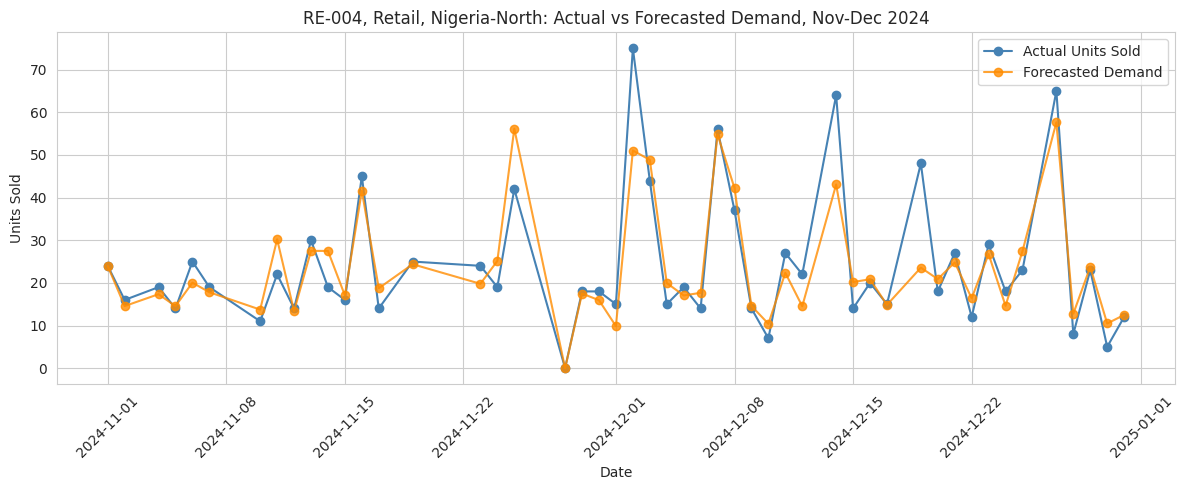

In [89]:
plt.figure(figsize=(12,5))
plt.plot(example['date'], example['units_sold'], marker='o', label='Actual Units Sold', color='steelblue')
plt.plot(example['date'], example['forecast_demand'], marker='o', label='Forecasted Demand', color='darkorange', alpha=0.8)
plt.title("RE-004, Retail, Nigeria-North: Actual vs Forecasted Demand, Nov-Dec 2024")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The forecast line tracks actual sales reasonably closely, rising and falling roughly in step rather than lagging behind. One point stands out: a sharp drop to zero actual sales, with the forecast also at zero. That specific date is checked directly next.

In [90]:
zero_day = example[example['units_sold'] == 0]
print(zero_day[['date','units_sold','forecast_demand','stock_available']].to_string(index=False))

      date  units_sold  forecast_demand  stock_available
2024-11-28           0              0.0                0


A genuine stockout: stock_available is 0 that day, not a forecasting failure. This is the same mechanic confirmed in Part 2 and validated in Part 4, when stock is at zero there is nothing to sell regardless of demand, and the model correctly forecasts close to zero along with it, a sign the model is behaving sensibly.

Where this specific forecast missed the most is worth showing too, not just the good parts.

In [91]:
example = example.copy()
example['abs_error'] = (example['units_sold'] - example['forecast_demand']).abs()
print(example.sort_values('abs_error', ascending=False)[
    ['date','units_sold','forecast_demand','promotion_flag','abs_error']
].head(5).to_string(index=False))

      date  units_sold  forecast_demand  promotion_flag  abs_error
2024-12-19          48        23.572022               0  24.427978
2024-12-02          75        51.040345               1  23.959655
2024-12-14          64        43.073584               1  20.926416
2024-11-25          42        56.166791               1  14.166791
2024-11-14          19        27.489656               0   8.489656


The two biggest misses, December 2nd and December 14th, happened on promotion days: actual sales spiked to 75 and 64, and the forecast moved up from its usual range but noticeably undershot the size of the spike. That fits Part 2 and Part 3, promotion_flag is a real, strong driver but only tells the model a promotion is happening, not how large it is, so the model predicts an average promotion effect rather than an unusually large one. The single biggest miss, December 19th, was not a promotion day at all: actual sales hit 48 against a forecast of 23.6, roughly double. Nothing in the feature set explains this one, it looks like a genuine, unexplained demand spike, the kind of noise ReadyMeal, with its already weak day to day autocorrelation from Part 2, seems more prone to than other categories.

## 5.3 Zooming Out, Actual Versus Forecast Across the Whole Business

The aggregated view across every sku, channel, and region combined is closer to what Mr Joseph would want for overall stock planning than one specific product line.

In [92]:
daily_compare = test.groupby('date').agg(
    actual=('units_sold','sum'),
    forecast=('forecast_demand','sum')
).reset_index()

print(daily_compare.head(5).to_string(index=False))

      date  actual    forecast
2024-11-01    3855 3991.295759
2024-11-02    3420 3620.587289
2024-11-03    3656 3793.851927
2024-11-04    3748 3818.792292
2024-11-05    3745 3846.015507


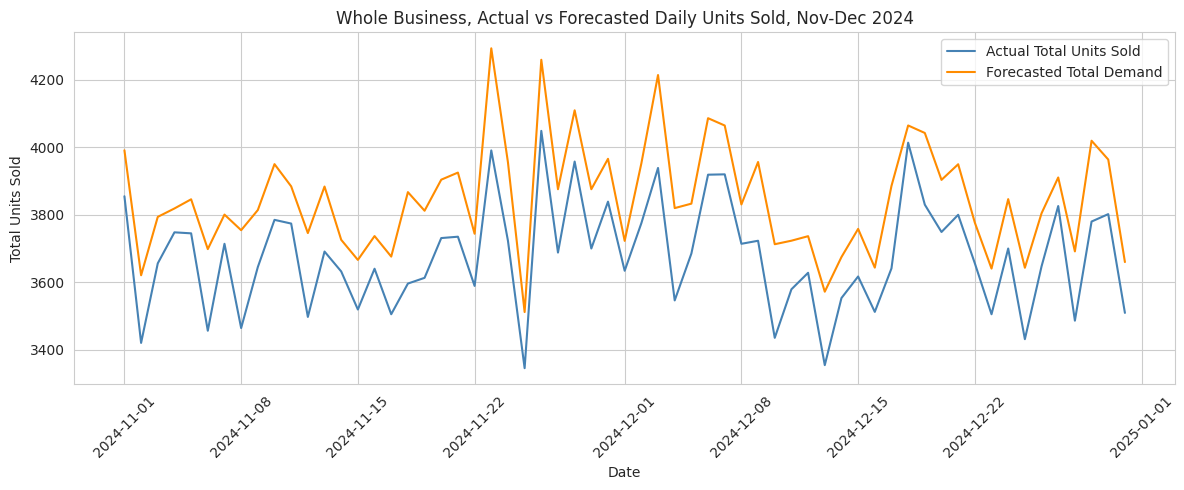

In [93]:
plt.figure(figsize=(12,5))
plt.plot(daily_compare['date'], daily_compare['actual'], label='Actual Total Units Sold', color='steelblue')
plt.plot(daily_compare['date'], daily_compare['forecast'], label='Forecasted Total Demand', color='darkorange')
plt.title("Whole Business, Actual vs Forecasted Daily Units Sold, Nov-Dec 2024")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

At the aggregated level the two lines sit close together throughout the test period, the same effect seen in Part 2, individual noise mostly washes out once summed together. Putting a number on how close comes next.

In [94]:
mae_aggregate = (daily_compare['actual'] - daily_compare['forecast']).abs().mean()
total_actual = daily_compare['actual'].sum()
total_forecast = daily_compare['forecast'].sum()
pct_diff = (total_forecast - total_actual) / total_actual * 100

print("MAE on daily aggregated totals:", round(mae_aggregate, 2), "units per day")
print("total actual units, test period:", total_actual)
print("total forecasted units, test period:", round(total_forecast, 1))
print("forecast is off from actual total by:", round(pct_diff, 2), "%")

MAE on daily aggregated totals: 170.52 units per day
total actual units, test period: 224212
total forecasted units, test period: 234613.6
forecast is off from actual total by: 4.64 %


At the whole-business level, the forecast overshoots total actual demand by about 4.64% across the full two-month test period, a small, consistent tendency to forecast slightly higher than what actually happens in aggregate. For Mr Joseph this is a modest, known bias, and erring slightly high on stock planning is the safer direction, since a small overestimate risks a bit of excess stock, while an underestimate risks an actual stockout, the more costly mistake.

## 5.4 Final Model Comparison, One Last Time, Clearly

The full comparison from Part 3, pulled together once more, since this is the number that answers the core question: is this model worth using over just guessing based on recent history.

In [95]:
results = pd.DataFrame([
    {'model': 'Naive baseline (84.95% coverage)', 'MAE': 8.826, 'RMSE': 12.203, 'MAPE': 62.81},
    {'model': '7 day moving average', 'MAE': 6.762, 'RMSE': 9.328, 'MAPE': 48.69},
    {'model': 'Linear Regression', 'MAE': 4.038, 'RMSE': 5.471, 'MAPE': 29.05},
    {'model': 'Random Forest (final model)', 'MAE': 3.264, 'RMSE': 4.569, 'MAPE': 23.93},
    {'model': 'Gradient Boosting', 'MAE': 3.281, 'RMSE': 4.562, 'MAPE': 23.63},
])
print(results.to_string(index=False))

                           model   MAE   RMSE  MAPE
Naive baseline (84.95% coverage) 8.826 12.203 62.81
            7 day moving average 6.762  9.328 48.69
               Linear Regression 4.038  5.471 29.05
     Random Forest (final model) 3.264  4.569 23.93
               Gradient Boosting 3.281  4.562 23.63


In [96]:
naive_mae, naive_rmse, naive_mape = 8.826, 12.203, 62.81
final_mae, final_rmse, final_mape = 3.264, 4.569, 23.93

mae_improve = (naive_mae - final_mae) / naive_mae * 100
rmse_improve = (naive_rmse - final_rmse) / naive_rmse * 100
mape_improve = (naive_mape - final_mape) / naive_mape * 100

print(f"MAE improvement over naive baseline: {mae_improve:.2f}%")
print(f"RMSE improvement over naive baseline: {rmse_improve:.2f}%")
print(f"MAPE improvement over naive baseline: {mape_improve:.2f}% (from {naive_mape:.2f}% down to {final_mape:.2f}%)")

MAE improvement over naive baseline: 63.02%
RMSE improvement over naive baseline: 62.56%
MAPE improvement over naive baseline: 61.90% (from 62.81% down to 23.93%)


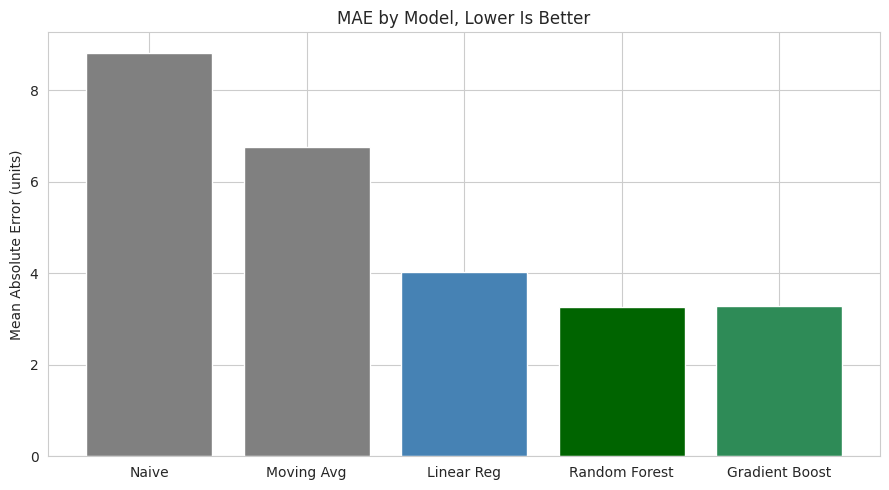

In [97]:
bars = ['Naive', 'Moving Avg', 'Linear Reg', 'Random Forest', 'Gradient Boost']
mae_vals = [8.826, 6.762, 4.038, 3.264, 3.281]

plt.figure(figsize=(9,5))
plt.bar(bars, mae_vals, color=['gray','gray','steelblue','darkgreen','seagreen'])
plt.title("MAE by Model, Lower Is Better")
plt.ylabel("Mean Absolute Error (units)")
plt.tight_layout()
plt.show()

This means, on an average day the forecast is off by about 3.3 units per sku, channel, region combination, down from about 8.8 units for just using yesterday's number, and down from about 62.8% average error to about 23.9%. That is a meaningful improvement, roughly cutting forecasting error by 60% across every metric checked, not just one cherry-picked measure.

## 5.5 What This Actually Means for Mr Joseph's Reordering Decisions

Combined with Part 4's inventory classification, this is the practical guidance the pipeline produces. For any sku, channel, region combination on a given day, current stock is checked against forecasted demand and sorted into one of four states: already out of stock, at risk of running out within the time a delivery would take to arrive, sitting in a healthy range, or carrying more stock than makes sense even in a worst-case delivery delay.

The at risk threshold, under 5 days of cover, is a direct reorder signal, tied to Mr Joseph's slowest observed delivery lead time, so anything below that line means an unlucky delivery delay could genuinely cause a stockout. The overstocked threshold, over 12 days of cover, flags where more capital is likely tied up in a specific sku, channel, region combination than actual demand justifies, and where the next reorder could reasonably be delayed or that stock shifted elsewhere.

## 5.6 Where the Risk Is, and Where It Is Not

Channel and region both came out fairly flat in Part 4, at risk rates within about half a percentage point of each other across Retail, Discount, and E-commerce, and across Nigeria-North, Nigeria-Central, and Nigeria-South. This data does not support pointing at any single channel or region as the source of stockout risk; the risk is fairly evenly spread across geography and channel.

In [98]:
category_risk = pd.DataFrame({
    'category': ['Juice','Milk','ReadyMeal','SnackBar','Yogurt'],
    'at_risk_pct': [0.22, 0.68, 11.85, 4.62, 1.08],
    'overstocked_pct': [40.26, 22.32, 0.13, 7.49, 12.86],
})
print(category_risk.to_string(index=False))

 category  at_risk_pct  overstocked_pct
    Juice         0.22            40.26
     Milk         0.68            22.32
ReadyMeal        11.85             0.13
 SnackBar         4.62             7.49
   Yogurt         1.08            12.86


Category is where the real, actionable story is. ReadyMeal sits at 11.85% at risk, more than three times any other category, and is essentially never overstocked (0.13%). This lines up with Part 2: ReadyMeal SKU RE-004 had the weakest day to day autocorrelation measured, meaning its demand is genuinely less predictable, making it harder to keep reliably stocked without running short or padding a large safety buffer.

Juice sits at the opposite extreme, 40.26% of its rows overstocked, by far the highest of any category, with an at risk rate near zero. Juice has only one SKU in the catalogue, JU-021, so there is no basket of similar products to smooth its demand, and a large stock buffer appears to be held for it that recent demand does not justify.

Concrete recommendation: Mr Joseph should prioritize tightening reorder timing for his ReadyMeal line, where real stockout risk is concentrated, and can likely scale back Juice stock without meaningfully increasing his risk of running out.

## 5.7 Being Honest About What This System Cannot Do Yet

Part 4 tested whether the at risk flag predicts an imminent stockout a few days ahead, and found it barely beats a random healthy-looking row, only a few percentage points of separation at 3, 7, and 14 day windows. Deliveries in this dataset do not appear reactive to how low current stock is, so today's stock position does not reliably indicate whether a delivery is arriving in time. This system is genuinely useful as a snapshot of where inventory stands right now, but not yet a reliable early warning system for a stockout three days out. If Mr Joseph's real replenishment process is more reactive to low stock than this synthetic dataset reflects, that gap may close on real data, but that would need testing against his real numbers.

The forecasting model has its own limits: it struggles more with unusually large promotion spikes, since promotion_flag only signals that a promotion is happening, not its size, and the single biggest miss in the example chart happened on a day with no promotion flag at all, an unexplained demand spike with no feature to catch it. At the aggregate business level, the forecast runs about 4.64% higher than actual total demand, a small but real bias worth stating rather than presenting the model as unbiased.

## 5.8 Final Summary

Across these five parts, a full demand forecasting and inventory risk pipeline was built for Mr Joseph's FMCG distribution business across Nigeria. The dataset's structure was confirmed and its Polish regional codes relabeled for the Nigerian storyline; every statistical assumption from the original plan was tested against the real data; a dataset-wide bug, missing calendar days across all 270 sku, channel, region series, was caught and fixed before it could silently corrupt the lag and rolling features.

The final model is a tuned random forest, cutting forecast error by roughly 60% across MAE, RMSE, and MAPE compared to a naive yesterday-based baseline, built on stock_available and promotion_flag as its two strongest signals, matching the correlation analysis in Part 2. Those forecasts became a days of cover metric, grounded in Mr Joseph's own observed delivery lead times rather than arbitrary round numbers, which reliably reflects current inventory health, though it is not yet a strong predictor of stockouts several days in advance.

The single most useful, specific finding across the project is the category-level split: ReadyMeal carries meaningfully more stockout risk than anything else in the catalogue, and Juice carries meaningfully more excess stock than its actual demand justifies. That is a concrete, evidence-backed place for Mr Joseph to focus attention first.